# FYDP Blood Cell Classification — Improved 90%+ Target Notebook

This notebook is a full upgraded version of the previous FYDP workflow. The aim is to improve the project honestly by fixing class imbalance, training stronger models, and comparing results using accuracy, balanced accuracy, macro F1-score, and class-wise performance.

**Main strategy used in this notebook:**

1. Use your existing Google Drive dataset path.
2. Crop blood cells from YOLO labels.
3. Create a balanced augmented training dataset.
4. Train an improved GNN baseline.
5. Train a CNN baseline.
6. Train a final Hybrid CNN + GNN model.
7. Evaluate models on both original test data and balanced fair test data.
8. Save results, models, graphs, reports, and a final app folder to Google Drive.

Run the notebook from top to bottom in Google Colab. Use GPU runtime.

## Cell 1 — Environment Setup

This cell checks GPU availability and installs PyTorch Geometric using the correct PyTorch/CUDA version. Run this first.

In [ ]:
# ============================================================
# 1) Environment setup
# ============================================================

import os, sys, subprocess, json, random, shutil, math, time
from pathlib import Path
from glob import glob

import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

# Install PyTorch Geometric matching the current torch/cuda in Colab.
TORCH_V = torch.__version__.split("+")[0]
CUDA_SUFFIX = "cpu" if torch.version.cuda is None else "cu" + torch.version.cuda.replace(".", "")
PYG_URL = f"https://data.pyg.org/whl/torch-{TORCH_V}+{CUDA_SUFFIX}.html"
print("Installing PyG from:", PYG_URL)

!pip -q install torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv -f {PYG_URL}
!pip -q install scikit-learn pandas matplotlib tqdm opencv-python reportlab gradio

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset
from torch.utils.data import DataLoader as TorchDataLoader

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

print("Environment ready.")
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
Installing PyG from: https://data.pyg.org/whl/torch-2.11.0+cu128.html
  Preparing metadata (setup.py) ... done
Environment ready.
Device: cuda


## Cell 2 — Reproducibility

This fixes the random seed so that experiments are more stable and easier to compare.

In [ ]:
# ============================================================
# 2) Reproducibility
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
print("Seed fixed:", SEED)

Seed fixed: 42


## Cell 3 — Mount Google Drive and Load Dataset Path

This uses the same dataset parent path from your previous notebook:

`/content/drive/MyDrive/Dataset`

The folder should contain `PBC-YOLO-721` and/or `PBC-YOLO-811`. By default, the notebook uses `PBC-YOLO-721` if available.

In [ ]:
# ============================================================
# 3) Google Drive dataset path
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

DATASET_PARENT = "/content/drive/MyDrive/Dataset"

p721 = os.path.join(DATASET_PARENT, "PBC-YOLO-721")
p811 = os.path.join(DATASET_PARENT, "PBC-YOLO-811")

assert os.path.isdir(DATASET_PARENT), f"Missing dataset parent folder: {DATASET_PARENT}"
assert os.path.isdir(p721) or os.path.isdir(p811), "Neither PBC-YOLO-721 nor PBC-YOLO-811 was found."

# Main dataset choice. Keep PBC-YOLO-721 because this was used in your previous project.
DATASET_ROOT = p721 if os.path.isdir(p721) else p811

PROJECT_DIR = "/content/drive/MyDrive/blood_cell_improved_project"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("Dataset parent:", DATASET_PARENT)
print("Using dataset:", DATASET_ROOT)
print("Project outputs will be saved to:", PROJECT_DIR)

Mounted at /content/drive
Dataset parent: /content/drive/MyDrive/Dataset
Using dataset: /content/drive/MyDrive/Dataset/PBC-YOLO-721
Project outputs will be saved to: /content/drive/MyDrive/blood_cell_improved_project


## Cell 4 — Read Class Names from `data.yaml`

This reads the 12 blood-cell class names automatically from the YOLO dataset YAML file.

In [ ]:
# ============================================================
# 4) Read class names from data.yaml
# ============================================================

import yaml

yaml_path = os.path.join(DATASET_ROOT, "data.yaml")
assert os.path.exists(yaml_path), f"Missing data.yaml: {yaml_path}"

with open(yaml_path, "r") as f:
    y = yaml.safe_load(f)

names = y.get("names", None)
assert names is not None, "data.yaml must contain 'names'"

if isinstance(names, dict):
    CLASS_NAMES = [names[i] for i in sorted(names.keys())]
else:
    CLASS_NAMES = list(names)

NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

with open(os.path.join(PROJECT_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Number of classes: 12
Classes: ['BA', 'BNE', 'EO', 'ERB', 'LY', 'MMY', 'MO', 'MY', 'PLT', 'PMY', 'RBC', 'SNE']


## Cell 5 — Resolve YOLO Image and Label Split Folders

This checks that `images/train`, `images/val`, `images/test`, and matching label folders exist.

In [ ]:
# ============================================================
# 5) Resolve split folders safely
# ============================================================

def resolve_split_dirs(root):
    img_root = os.path.join(root, "images")
    lbl_root = os.path.join(root, "labels")
    assert os.path.isdir(img_root), f"Missing: {img_root}"
    assert os.path.isdir(lbl_root), f"Missing: {lbl_root}"

    splits = {}
    for s in ["train", "val", "test"]:
        splits[s] = {
            "img": os.path.join(img_root, s),
            "lbl": os.path.join(lbl_root, s),
        }
        assert os.path.isdir(splits[s]["img"]), f"Missing images/{s}"
        assert os.path.isdir(splits[s]["lbl"]), f"Missing labels/{s}"
    return splits

SPLITS = resolve_split_dirs(DATASET_ROOT)
print(json.dumps(SPLITS, indent=2))

{
  "train": {
    "img": "/content/drive/MyDrive/Dataset/PBC-YOLO-721/images/train",
    "lbl": "/content/drive/MyDrive/Dataset/PBC-YOLO-721/labels/train"
  },
  "val": {
    "img": "/content/drive/MyDrive/Dataset/PBC-YOLO-721/images/val",
    "lbl": "/content/drive/MyDrive/Dataset/PBC-YOLO-721/labels/val"
  },
  "test": {
    "img": "/content/drive/MyDrive/Dataset/PBC-YOLO-721/images/test",
    "lbl": "/content/drive/MyDrive/Dataset/PBC-YOLO-721/labels/test"
  }
}


## Cell 6 — Crop Blood Cells from YOLO Labels

This cell reads the original YOLO images and labels, crops every blood cell, and saves the crop into class folders. It is written safely so if crops already exist, it does not repeat the whole cropping process unless `FORCE_RECROP = True`.

In [ ]:
# ============================================================
# 6) Crop cells from YOLO labels
# ============================================================

OUT_CROPS = "/content/pbc_crops"
FORCE_RECROP = False

def safe_parse_yolo_line(line):
    s = line.strip().replace(",", " ")
    if (not s) or s.startswith("#"):
        return None
    parts = s.split()
    if len(parts) < 5:
        return None
    try:
        cls = int(float(parts[0].rstrip(":")))
        xc, yc, bw, bh = map(float, parts[1:5])
        return cls, xc, yc, bw, bh
    except Exception:
        return None

def yolo_to_xyxy(xc, yc, bw, bh, W, H):
    x1 = int(round((xc - bw / 2) * W))
    y1 = int(round((yc - bh / 2) * H))
    x2 = int(round((xc + bw / 2) * W))
    y2 = int(round((yc + bh / 2) * H))
    x1 = max(0, min(W - 1, x1)); y1 = max(0, min(H - 1, y1))
    x2 = max(0, min(W - 1, x2)); y2 = max(0, min(H - 1, y2))
    if x2 <= x1 or y2 <= y1:
        return None
    return x1, y1, x2, y2

def list_images(img_dir):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    out = []
    for e in exts:
        out += glob(os.path.join(img_dir, e))
    return sorted(out)

def count_existing_crops(root):
    total = 0
    for split in ["train", "val", "test"]:
        for cname in CLASS_NAMES:
            total += len(glob(os.path.join(root, split, cname, "*.png")))
    return total

def make_crops_for_split(img_dir, lbl_dir, split, pad=2, min_size=20):
    img_paths = list_images(img_dir)
    total_crops, missing_lbl, bad_lines, bad_images = 0, 0, 0, 0

    for ip in tqdm(img_paths, desc=f"Cropping {split}"):
        img = cv2.imread(ip)
        if img is None:
            bad_images += 1
            continue
        H, W = img.shape[:2]
        stem = Path(ip).stem
        lp = os.path.join(lbl_dir, stem + ".txt")
        if not os.path.exists(lp):
            missing_lbl += 1
            continue

        with open(lp, "r") as f:
            lines = f.readlines()

        box_id = 0
        for ln in lines:
            parsed = safe_parse_yolo_line(ln)
            if parsed is None:
                if ln.strip():
                    bad_lines += 1
                continue

            cls, xc, yc, bw, bh = parsed
            if not (0 <= cls < NUM_CLASSES):
                continue

            xyxy = yolo_to_xyxy(xc, yc, bw, bh, W, H)
            if xyxy is None:
                continue
            x1, y1, x2, y2 = xyxy

            x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
            x2p = min(W - 1, x2 + pad); y2p = min(H - 1, y2 + pad)

            cw, ch = (x2p - x1p), (y2p - y1p)
            if cw < min_size or ch < min_size:
                continue

            crop = img[y1p:y2p, x1p:x2p].copy()
            cname = CLASS_NAMES[cls]
            out_dir = os.path.join(OUT_CROPS, split, cname)
            os.makedirs(out_dir, exist_ok=True)

            out_name = f"{stem}_box{box_id}.png"
            cv2.imwrite(os.path.join(out_dir, out_name), crop)
            total_crops += 1
            box_id += 1

    return {
        "images": len(img_paths),
        "crops": total_crops,
        "missing_lbl": missing_lbl,
        "bad_lines": bad_lines,
        "bad_images": bad_images,
    }

if FORCE_RECROP or count_existing_crops(OUT_CROPS) == 0:
    if os.path.exists(OUT_CROPS):
        shutil.rmtree(OUT_CROPS)
    os.makedirs(OUT_CROPS, exist_ok=True)

    crop_stats = {}
    for s in ["train", "val", "test"]:
        crop_stats[s] = make_crops_for_split(SPLITS[s]["img"], SPLITS[s]["lbl"], s)

    with open(os.path.join(PROJECT_DIR, "crop_stats.json"), "w") as f:
        json.dump(crop_stats, f, indent=2)
else:
    crop_stats = {"status": "Existing crops found, cropping skipped."}

print("Crop stats:")
print(json.dumps(crop_stats, indent=2))
print("Crops saved at:", OUT_CROPS)
print("Total crop files:", count_existing_crops(OUT_CROPS))

Cropping test: 100%|██████████| 1688/1688 [25:49<00:00,  1.09it/s]


Crop stats:
{
  "train": {
    "images": 11821,
    "crops": 192833,
    "missing_lbl": 10,
    "bad_lines": 366,
    "bad_images": 0
  },
  "val": {
    "images": 3376,
    "crops": 38407,
    "missing_lbl": 2,
    "bad_lines": 1049,
    "bad_images": 0
  },
  "test": {
    "images": 1688,
    "crops": 28350,
    "missing_lbl": 0,
    "bad_lines": 0,
    "bad_images": 0
  }
}
Crops saved at: /content/pbc_crops
Total crop files: 259590


## Cell 7 — Check Original Crop Class Distribution

This shows the original imbalance. Usually RBC dominates heavily, which makes accuracy misleading.

split,test,train,val
class,,,
BA,94,817,259
BNE,170,1197,324
EO,321,1841,592
ERB,169,1202,279
LY,125,799,135
MMY,107,724,59
MO,148,1017,113
MY,120,784,154
PLT,1371,8956,1744


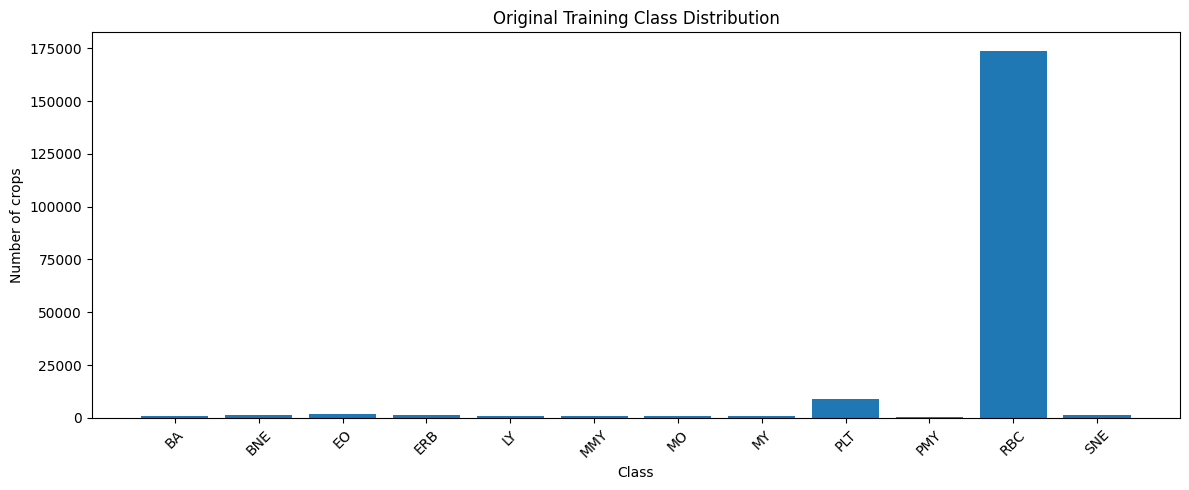

In [ ]:
# ============================================================
# 7) Original crop distribution
# ============================================================

from collections import Counter

def count_split_classes(root, split):
    rows = []
    for cname in CLASS_NAMES:
        n = len(glob(os.path.join(root, split, cname, "*.png")))
        rows.append({"split": split, "class": cname, "count": n})
    return rows

orig_counts = []
for split in ["train", "val", "test"]:
    orig_counts.extend(count_split_classes(OUT_CROPS, split))

orig_counts_df = pd.DataFrame(orig_counts)
display(orig_counts_df.pivot(index="class", columns="split", values="count").fillna(0).astype(int))
orig_counts_df.to_csv(os.path.join(PROJECT_DIR, "original_crop_class_counts.csv"), index=False)

plt.figure(figsize=(12, 5))
train_counts = orig_counts_df[orig_counts_df["split"] == "train"].set_index("class").loc[CLASS_NAMES]["count"]
plt.bar(CLASS_NAMES, train_counts.values)
plt.title("Original Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of crops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "original_train_distribution.png"), dpi=200)
plt.show()

## Cell 8 — Build Balanced Augmented Training Dataset

This is the most important data-improvement cell.

What happens here:

- Large classes such as RBC are downsampled.
- Small classes are increased using safe augmentation.
- Only training data is augmented.
- Validation and test data stay clean.

Default target is `3000` training crops per class. You can increase to `4000` if your Colab GPU/runtime is stable.

In [ ]:
# ============================================================
# 8) Create balanced augmented training dataset
# ============================================================

BALANCED_DIR = "/content/pbc_balanced_aug"
TARGET_PER_CLASS = 3000       # Good starting point. Try 4000 later if training is stable.
FORCE_REBALANCE = False

VALID_EXTS = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]

def image_files_in_dir(d):
    files = []
    for e in VALID_EXTS:
        files.extend(glob(os.path.join(d, e)))
    return sorted(files)

def safe_imwrite(path, img):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    ok = cv2.imwrite(path, img)
    if not ok:
        raise RuntimeError(f"Could not write image: {path}")

def augment_blood_cell(img_bgr, rng):
    """Safe augmentation for blood cell crops. Avoid strong color distortion."""
    img = img_bgr.copy()
    h, w = img.shape[:2]

    # Random rotation with small scale variation
    angle = rng.uniform(0, 360)
    scale = rng.uniform(0.92, 1.08)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    # Random flips
    if rng.random() < 0.5:
        img = cv2.flip(img, 1)
    if rng.random() < 0.3:
        img = cv2.flip(img, 0)

    # Slight brightness/contrast
    alpha = rng.uniform(0.88, 1.12)  # contrast
    beta = rng.uniform(-12, 12)      # brightness
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Light blur sometimes
    if rng.random() < 0.20:
        img = cv2.GaussianBlur(img, (3, 3), 0)

    # Very light noise sometimes
    if rng.random() < 0.25:
        noise = rng.normalvariate(0, 1)
        noise_map = np.random.normal(0, abs(noise) + 2.0, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise_map, 0, 255).astype(np.uint8)

    return img

def balanced_dir_has_data(root):
    total = 0
    for cname in CLASS_NAMES:
        total += len(glob(os.path.join(root, "train", cname, "*.png")))
    return total > 0

rng = random.Random(SEED)
np.random.seed(SEED)

if FORCE_REBALANCE or not balanced_dir_has_data(BALANCED_DIR):
    if os.path.exists(BALANCED_DIR):
        shutil.rmtree(BALANCED_DIR)
    os.makedirs(BALANCED_DIR, exist_ok=True)

    balance_log = []

    # Train: balanced + augmented
    for cname in CLASS_NAMES:
        src_dir = os.path.join(OUT_CROPS, "train", cname)
        out_dir = os.path.join(BALANCED_DIR, "train", cname)
        os.makedirs(out_dir, exist_ok=True)

        files = image_files_in_dir(src_dir)
        rng.shuffle(files)
        original_count = len(files)

        if original_count == 0:
            print(f"Warning: no training images found for class {cname}")
            balance_log.append({"split": "train", "class": cname, "original": 0, "final": 0, "augmented": 0})
            continue

        # If class is larger than target, downsample.
        if original_count >= TARGET_PER_CLASS:
            selected = files[:TARGET_PER_CLASS]
            for i, fp in enumerate(selected):
                img = cv2.imread(fp)
                if img is not None:
                    safe_imwrite(os.path.join(out_dir, f"real_{i:05d}.png"), img)
            final_count = TARGET_PER_CLASS
            augmented_count = 0

        # If class is smaller than target, copy real images and add augmented versions.
        else:
            copied = 0
            for i, fp in enumerate(files):
                img = cv2.imread(fp)
                if img is not None:
                    safe_imwrite(os.path.join(out_dir, f"real_{i:05d}.png"), img)
                    copied += 1

            aug_id = 0
            while copied < TARGET_PER_CLASS:
                fp = rng.choice(files)
                img = cv2.imread(fp)
                if img is None:
                    continue
                aug = augment_blood_cell(img, rng)
                safe_imwrite(os.path.join(out_dir, f"aug_{aug_id:05d}.png"), aug)
                copied += 1
                aug_id += 1

            final_count = copied
            augmented_count = aug_id

        balance_log.append({
            "split": "train",
            "class": cname,
            "original": original_count,
            "final": final_count,
            "augmented": augmented_count,
        })

    # Val/Test: clean copy only, no augmentation.
    for split in ["val", "test"]:
        for cname in CLASS_NAMES:
            src_dir = os.path.join(OUT_CROPS, split, cname)
            out_dir = os.path.join(BALANCED_DIR, split, cname)
            os.makedirs(out_dir, exist_ok=True)
            files = image_files_in_dir(src_dir)
            for i, fp in enumerate(files):
                img = cv2.imread(fp)
                if img is not None:
                    safe_imwrite(os.path.join(out_dir, f"real_{i:05d}.png"), img)
            balance_log.append({
                "split": split,
                "class": cname,
                "original": len(files),
                "final": len(files),
                "augmented": 0,
            })

    balance_df = pd.DataFrame(balance_log)
    balance_df.to_csv(os.path.join(PROJECT_DIR, "balanced_augmentation_log.csv"), index=False)
else:
    print("Existing balanced dataset found. Set FORCE_REBALANCE=True to recreate it.")
    balance_df = pd.read_csv(os.path.join(PROJECT_DIR, "balanced_augmentation_log.csv")) if os.path.exists(os.path.join(PROJECT_DIR, "balanced_augmentation_log.csv")) else pd.DataFrame()

print("Balanced dataset saved at:", BALANCED_DIR)
if not balance_df.empty:
    display(balance_df)

Balanced dataset saved at: /content/pbc_balanced_aug


,split,class,original,final,augmented
0,train,BA,817,3000,2183
1,train,BNE,1197,3000,1803
2,train,EO,1841,3000,1159
3,train,ERB,1202,3000,1798
4,train,LY,799,3000,2201
5,train,MMY,724,3000,2276
6,train,MO,1017,3000,1983
7,train,MY,784,3000,2216
8,train,PLT,8956,3000,0
9,train,PMY,438,3000,2562


## Cell 9 — Check Balanced Dataset Distribution

This confirms that the training set is now balanced while validation and test remain clean.

split,test,train,val
class,,,
BA,94,3000,259
BNE,170,3000,324
EO,321,3000,592
ERB,169,3000,279
LY,125,3000,135
MMY,107,3000,59
MO,148,3000,113
MY,120,3000,154
PLT,1371,3000,1744


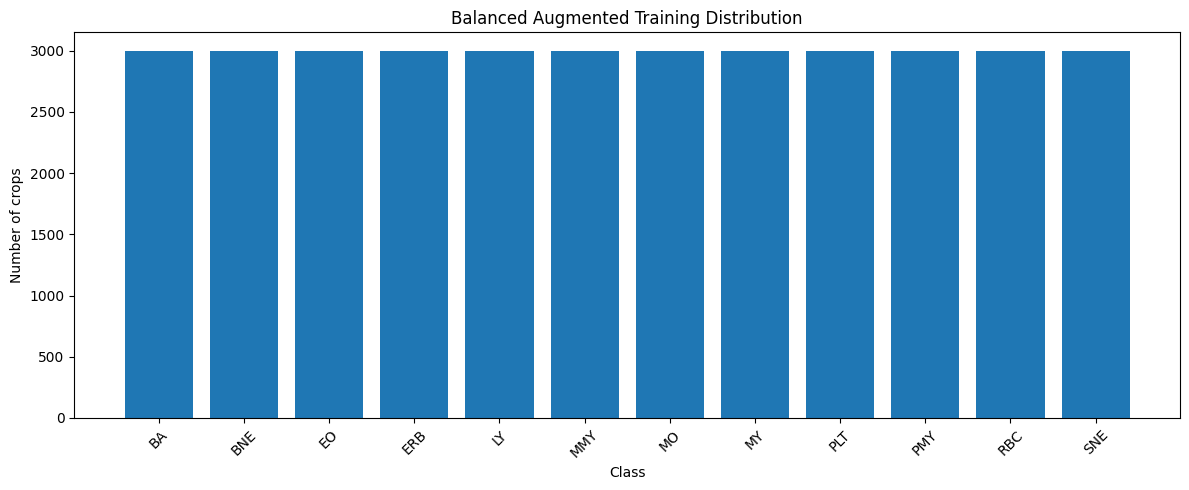

In [ ]:
# ============================================================
# 9) Balanced dataset distribution
# ============================================================

balanced_counts = []
for split in ["train", "val", "test"]:
    balanced_counts.extend(count_split_classes(BALANCED_DIR, split))

balanced_counts_df = pd.DataFrame(balanced_counts)
display(balanced_counts_df.pivot(index="class", columns="split", values="count").fillna(0).astype(int))
balanced_counts_df.to_csv(os.path.join(PROJECT_DIR, "balanced_class_counts.csv"), index=False)

plt.figure(figsize=(12, 5))
train_counts = balanced_counts_df[balanced_counts_df["split"] == "train"].set_index("class").loc[CLASS_NAMES]["count"]
plt.bar(CLASS_NAMES, train_counts.values)
plt.title("Balanced Augmented Training Distribution")
plt.xlabel("Class")
plt.ylabel("Number of crops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "balanced_train_distribution.png"), dpi=200)
plt.show()

## Cell 10 — Create a Balanced Fair Test Subset

The original test set is kept for real-world performance. This cell also creates a balanced test subset so that each class gets fair importance during evaluation.

In [ ]:
# ============================================================
# 10) Create balanced fair test subset
# ============================================================

FAIR_TEST_ROOT = "/content/pbc_fair_test"
FAIR_TEST_PER_CLASS_CAP = 500
FORCE_FAIR_TEST = False

def fair_test_has_data(root):
    return sum(len(glob(os.path.join(root, "test", c, "*.png"))) for c in CLASS_NAMES) > 0

rng = random.Random(SEED)

if FORCE_FAIR_TEST or not fair_test_has_data(FAIR_TEST_ROOT):
    if os.path.exists(FAIR_TEST_ROOT):
        shutil.rmtree(FAIR_TEST_ROOT)
    os.makedirs(FAIR_TEST_ROOT, exist_ok=True)

    test_counts = []
    for cname in CLASS_NAMES:
        files = image_files_in_dir(os.path.join(BALANCED_DIR, "test", cname))
        test_counts.append(len(files))

    positive_counts = [c for c in test_counts if c > 0]
    assert positive_counts, "No test images found."
    fair_n = min(min(positive_counts), FAIR_TEST_PER_CLASS_CAP)
    print("Fair test samples per class:", fair_n)

    fair_log = []
    for cname in CLASS_NAMES:
        src_dir = os.path.join(BALANCED_DIR, "test", cname)
        out_dir = os.path.join(FAIR_TEST_ROOT, "test", cname)
        os.makedirs(out_dir, exist_ok=True)
        files = image_files_in_dir(src_dir)
        rng.shuffle(files)
        selected = files[:fair_n]
        for i, fp in enumerate(selected):
            img = cv2.imread(fp)
            if img is not None:
                safe_imwrite(os.path.join(out_dir, f"fair_{i:05d}.png"), img)
        fair_log.append({"class": cname, "selected": len(selected), "available": len(files)})

    fair_df = pd.DataFrame(fair_log)
    fair_df.to_csv(os.path.join(PROJECT_DIR, "fair_test_counts.csv"), index=False)
else:
    fair_df = pd.read_csv(os.path.join(PROJECT_DIR, "fair_test_counts.csv")) if os.path.exists(os.path.join(PROJECT_DIR, "fair_test_counts.csv")) else pd.DataFrame()

print("Fair test root:", FAIR_TEST_ROOT)
if not fair_df.empty:
    display(fair_df)

Fair test samples per class: 65
Fair test root: /content/pbc_fair_test


,class,selected,available
0,BA,65,94
1,BNE,65,170
2,EO,65,321
3,ERB,65,169
4,LY,65,125
5,MMY,65,107
6,MO,65,148
7,MY,65,120
8,PLT,65,1371
9,PMY,65,65


## Cell 11 — Morphology Graph Feature Extraction

This keeps the GNN idea from your project. It creates graph nodes for the whole cell, nucleus, and cytoplasm, then extracts morphology/color features for each node.

In [ ]:
# ============================================================
# 11) Morphology segmentation and graph helpers
# ============================================================

def segment_cell_mask(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Make foreground = cell.
    if th.mean() > 127:
        th = 255 - th

    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)
    return th

def segment_nucleus_kmeans(img_bgr, min_ratio=0.01, max_ratio=0.75):
    cell_mask = segment_cell_mask(img_bgr)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    ys, xs = np.where(cell_mask > 0)
    if len(xs) < 80:
        return np.zeros_like(cell_mask)

    feats = np.stack([lab[ys, xs, 1], lab[ys, xs, 2], gray[ys, xs]], axis=1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 60, 0.2)
    _, labels, centers = cv2.kmeans(feats, 2, None, criteria, 5, cv2.KMEANS_PP_CENTERS)

    # Nucleus is usually darker.
    nuc_cluster = int(np.argmin(centers[:, 2]))
    nuc_mask = np.zeros_like(cell_mask)
    pick = (labels.flatten() == nuc_cluster)
    nuc_mask[ys[pick], xs[pick]] = 255

    nuc_mask = cv2.morphologyEx(nuc_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    nuc_mask = cv2.morphologyEx(nuc_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)

    cnts, _ = cv2.findContours(nuc_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final = np.zeros_like(nuc_mask)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        nucleus_area = cv2.contourArea(c)
        cell_area = float(np.count_nonzero(cell_mask))
        ratio = nucleus_area / (cell_area + 1e-6)
        if min_ratio < ratio < max_ratio:
            cv2.drawContours(final, [c], -1, 255, -1)
    return final

def region_features(img_bgr, mask):
    if mask is None or np.count_nonzero(mask) < 10:
        return np.zeros(12, dtype=np.float32)

    ys, xs = np.where(mask > 0)
    region = img_bgr[ys, xs]
    area = float(len(xs))
    H, W = img_bgr.shape[:2]
    area_norm = area / float(H * W + 1e-6)
    x_mean = float(xs.mean()) / float(W + 1e-6)
    y_mean = float(ys.mean()) / float(H + 1e-6)

    b_mean, g_mean, r_mean = region.mean(axis=0) / 255.0
    b_std, g_std, r_std = region.std(axis=0) / 255.0

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        perim = cv2.arcLength(c, True)
        contour_area = cv2.contourArea(c)
        perim_norm = float(perim) / float(2 * (H + W) + 1e-6)
        circularity = float(4 * np.pi * contour_area / ((perim ** 2) + 1e-6))
    else:
        perim_norm = 0.0
        circularity = 0.0

    return np.array([
        area_norm, x_mean, y_mean,
        b_mean, g_mean, r_mean,
        b_std, g_std, r_std,
        perim_norm, circularity,
        1.0,
    ], dtype=np.float32)

def build_cell_graph(img_bgr):
    """
    Graph nodes:
      0: whole cell
      1: nucleus, if detected
      2: cytoplasm, if detected
    """
    cell_mask = segment_cell_mask(img_bgr)
    nuc_mask = segment_nucleus_kmeans(img_bgr)

    cyto_mask = None
    if np.count_nonzero(nuc_mask) > 20:
        cyto_mask = cv2.bitwise_and(cell_mask, cv2.bitwise_not(nuc_mask))

    node_feats = []
    node_types = []

    node_feats.append(region_features(img_bgr, cell_mask))
    node_types.append(0)

    if np.count_nonzero(nuc_mask) > 20:
        node_feats.append(region_features(img_bgr, nuc_mask))
        node_types.append(1)
        if cyto_mask is not None and np.count_nonzero(cyto_mask) > 20:
            node_feats.append(region_features(img_bgr, cyto_mask))
            node_types.append(2)

    x = torch.tensor(np.stack(node_feats, axis=0), dtype=torch.float)
    n = x.size(0)
    edges = []
    for i in range(n):
        for j in range(n):
            if i != j:
                edges.append([i, j])

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return x, edge_index, torch.tensor(node_types, dtype=torch.long)

print("Graph feature helpers are ready.")

Graph feature helpers are ready.


## Cell 12 — Dataset Classes for GNN, CNN, and Hybrid Model

This cell creates reusable dataset classes. The same crops can be used for:

- GNN-only model
- CNN-only model
- Hybrid CNN + GNN model

In [ ]:
# ============================================================
# 12) Dataset classes
# ============================================================

IMG_SIZE = 224
IMAGE_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGE_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_image_tensor(fp, img_size=IMG_SIZE):
    img_bgr = cv2.imread(fp)
    if img_bgr is None:
        img_bgr = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    img = img_rgb.astype(np.float32) / 255.0
    img = (img - IMAGE_MEAN) / IMAGE_STD
    img = np.transpose(img, (2, 0, 1))
    return torch.tensor(img, dtype=torch.float32)


def collect_items(root_dir, split):
    items = []
    for cname in CLASS_NAMES:
        d = os.path.join(root_dir, split, cname)
        if not os.path.isdir(d):
            continue
        for fp in image_files_in_dir(d):
            items.append((fp, CLASS_TO_IDX[cname]))
    rng = random.Random(SEED)
    rng.shuffle(items)
    return items

class PBCGraphDataset(TorchDataset):
    def __init__(self, root_dir, split, cache_graphs=True):
        self.items = collect_items(root_dir, split)
        self.cache_graphs = cache_graphs
        self.cache = {} if cache_graphs else None

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fp, y = self.items[idx]
        if self.cache_graphs and fp in self.cache:
            data = self.cache[fp].clone()
            data.y = torch.tensor([y], dtype=torch.long)
            data.path = fp
            return data

        img = cv2.imread(fp)
        if img is None:
            x = torch.zeros((1, 12), dtype=torch.float)
            edge_index = torch.empty((2, 0), dtype=torch.long)
            node_types = torch.tensor([0], dtype=torch.long)
        else:
            x, edge_index, node_types = build_cell_graph(img)

        data = Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.long))
        data.node_types = node_types
        data.path = fp

        if self.cache_graphs:
            self.cache[fp] = data.clone()
        return data

class PBCImageGraphDataset(TorchDataset):
    def __init__(self, root_dir, split, cache_graphs=True):
        self.items = collect_items(root_dir, split)
        self.cache_graphs = cache_graphs
        self.graph_cache = {} if cache_graphs else None

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fp, y = self.items[idx]
        image_tensor = load_image_tensor(fp)

        if self.cache_graphs and fp in self.graph_cache:
            graph = self.graph_cache[fp].clone()
            graph.y = torch.tensor([y], dtype=torch.long)
            graph.path = fp
            return image_tensor, graph, torch.tensor(y, dtype=torch.long), fp

        img = cv2.imread(fp)
        if img is None:
            x = torch.zeros((1, 12), dtype=torch.float)
            edge_index = torch.empty((2, 0), dtype=torch.long)
            node_types = torch.tensor([0], dtype=torch.long)
        else:
            x, edge_index, node_types = build_cell_graph(img)

        graph = Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.long))
        graph.node_types = node_types
        graph.path = fp

        if self.cache_graphs:
            self.graph_cache[fp] = graph.clone()
        return image_tensor, graph, torch.tensor(y, dtype=torch.long), fp


def hybrid_collate(batch):
    images, graphs, labels, paths = zip(*batch)
    images = torch.stack(images, dim=0)
    graphs = Batch.from_data_list(list(graphs))
    labels = torch.stack(labels, dim=0)
    return images, graphs, labels, list(paths)

print("Dataset classes are ready.")

Dataset classes are ready.


## Cell 13 — Create Datasets and DataLoaders

This prepares loaders for original test, balanced fair test, GNN training, CNN training, and hybrid training.

In [ ]:
# ============================================================
# 13) Create datasets and dataloaders
# ============================================================

BATCH_SIZE_GRAPH = 128
BATCH_SIZE_IMAGE = 32
NUM_WORKERS = 2

# GNN datasets
train_graph_ds = PBCGraphDataset(BALANCED_DIR, "train", cache_graphs=True)
val_graph_ds = PBCGraphDataset(BALANCED_DIR, "val", cache_graphs=True)
test_graph_ds = PBCGraphDataset(BALANCED_DIR, "test", cache_graphs=True)
fair_graph_ds = PBCGraphDataset(FAIR_TEST_ROOT, "test", cache_graphs=True)

# CNN/Hybrid datasets
train_img_graph_ds = PBCImageGraphDataset(BALANCED_DIR, "train", cache_graphs=True)
val_img_graph_ds = PBCImageGraphDataset(BALANCED_DIR, "val", cache_graphs=True)
test_img_graph_ds = PBCImageGraphDataset(BALANCED_DIR, "test", cache_graphs=True)
fair_img_graph_ds = PBCImageGraphDataset(FAIR_TEST_ROOT, "test", cache_graphs=True)

# GNN loaders
train_graph_loader = PyGDataLoader(train_graph_ds, batch_size=BATCH_SIZE_GRAPH, shuffle=True)
val_graph_loader = PyGDataLoader(val_graph_ds, batch_size=BATCH_SIZE_GRAPH, shuffle=False)
test_graph_loader = PyGDataLoader(test_graph_ds, batch_size=BATCH_SIZE_GRAPH, shuffle=False)
fair_graph_loader = PyGDataLoader(fair_graph_ds, batch_size=BATCH_SIZE_GRAPH, shuffle=False)

# Image/Hybrid loaders
train_hybrid_loader = TorchDataLoader(train_img_graph_ds, batch_size=BATCH_SIZE_IMAGE, shuffle=True, collate_fn=hybrid_collate, num_workers=0)
val_hybrid_loader = TorchDataLoader(val_img_graph_ds, batch_size=BATCH_SIZE_IMAGE, shuffle=False, collate_fn=hybrid_collate, num_workers=0)
test_hybrid_loader = TorchDataLoader(test_img_graph_ds, batch_size=BATCH_SIZE_IMAGE, shuffle=False, collate_fn=hybrid_collate, num_workers=0)
fair_hybrid_loader = TorchDataLoader(fair_img_graph_ds, batch_size=BATCH_SIZE_IMAGE, shuffle=False, collate_fn=hybrid_collate, num_workers=0)

print("GNN dataset sizes:", len(train_graph_ds), len(val_graph_ds), len(test_graph_ds), len(fair_graph_ds))
print("Image/Hybrid dataset sizes:", len(train_img_graph_ds), len(val_img_graph_ds), len(test_img_graph_ds), len(fair_img_graph_ds))

GNN dataset sizes: 36000 38407 28350 780
Image/Hybrid dataset sizes: 36000 38407 28350 780


## Cell 14 — Model Definitions

This cell defines three models:

1. **Improved GNN baseline** — keeps your original GNN idea.
2. **CNN baseline** — learns stronger visual features.
3. **Hybrid CNN + GNN** — final proposed model combining visual features and morphology graph features.

In [ ]:
# ============================================================
# 14) Model definitions
# ============================================================

try:
    from torchvision.models import resnet18, ResNet18_Weights
except Exception as e:
    print("torchvision import issue:", e)
    !pip -q install torchvision
    from torchvision.models import resnet18, ResNet18_Weights

class GCNClassifier(nn.Module):
    def __init__(self, in_dim=12, hidden=96, num_classes=NUM_CLASSES, dropout=0.30):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.dropout = dropout
        self.lin = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        g = global_mean_pool(x, batch)
        return self.lin(g)


def build_resnet18_backbone(pretrained=True):
    try:
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)
    except Exception as e:
        print("Pretrained weights could not be loaded. Using random initialization.")
        print("Reason:", e)
        backbone = resnet18(weights=None)
    feat_dim = backbone.fc.in_features
    backbone.fc = nn.Identity()
    return backbone, feat_dim

class CNNClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.35, pretrained=True):
        super().__init__()
        self.backbone, feat_dim = build_resnet18_backbone(pretrained=pretrained)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, images):
        feat = self.backbone(images)
        return self.classifier(feat)

class GraphEncoder(nn.Module):
    def __init__(self, in_dim=12, hidden=96, dropout=0.25):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        g = global_mean_pool(x, batch)
        return g

class HybridCNNGNNClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.35, pretrained=True):
        super().__init__()
        self.cnn_backbone, cnn_dim = build_resnet18_backbone(pretrained=pretrained)
        self.graph_encoder = GraphEncoder(in_dim=12, hidden=96, dropout=0.25)
        self.fusion = nn.Sequential(
            nn.Linear(cnn_dim + 96, 384),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, images, graphs):
        image_feat = self.cnn_backbone(images)
        graph_feat = self.graph_encoder(graphs)
        fused = torch.cat([image_feat, graph_feat], dim=1)
        return self.fusion(fused)

print("Models are defined.")

Models are defined.


## Cell 15 — Training and Evaluation Helper Functions

These functions are shared by all models. The model is saved using validation macro F1-score, not only accuracy. This is important because the dataset is imbalanced.

In [ ]:
# ============================================================
# 15) Training and evaluation helper functions
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

RESULTS_DIR = "/content/fydp_improved_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def compute_basic_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def batch_to_device(batch, model_type):
    if model_type == "gnn":
        graphs = batch.to(DEVICE)
        labels = graphs.y.view(-1).to(DEVICE)
        return None, graphs, labels, getattr(graphs, "path", None)
    else:
        images, graphs, labels, paths = batch
        images = images.to(DEVICE)
        graphs = graphs.to(DEVICE)
        labels = labels.to(DEVICE).view(-1)
        return images, graphs, labels, paths

def forward_by_type(model, images, graphs, model_type):
    if model_type == "gnn":
        return model(graphs)
    if model_type == "cnn":
        return model(images)
    if model_type == "hybrid":
        return model(images, graphs)
    raise ValueError(f"Unknown model_type: {model_type}")

def run_epoch(model, loader, criterion, optimizer=None, model_type="cnn"):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in loader:
        images, graphs, labels, _ = batch_to_device(batch, model_type)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = forward_by_type(model, images, graphs, model_type)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()

        total_loss += float(loss.item()) * labels.size(0)
        preds = logits.argmax(dim=1)
        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    metrics = compute_basic_metrics(all_true, all_pred)
    metrics["loss"] = total_loss / max(len(all_true), 1)
    return metrics

def train_model(model, train_loader, val_loader, model_type, save_path, epochs=30, patience=8, lr=1e-4, weight_decay=1e-4):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_val_macro_f1 = -1.0
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer, model_type=model_type)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, model_type=model_type)
        scheduler.step(val_metrics["macro_f1"])

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        improved = val_metrics["macro_f1"] > best_val_macro_f1
        if improved:
            best_val_macro_f1 = val_metrics["macro_f1"]
            bad_epochs = 0
            torch.save({
                "model_type": model_type,
                "model_state_dict": model.state_dict(),
                "class_names": CLASS_NAMES,
                "best_val_macro_f1": best_val_macro_f1,
                "img_size": IMG_SIZE,
            }, save_path)
        else:
            bad_epochs += 1

        print(
            f"Epoch {epoch:03d} | "
            f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} macroF1 {train_metrics['macro_f1']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} balAcc {val_metrics['balanced_accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f} | "
            f"best macroF1 {best_val_macro_f1:.4f} | lr {optimizer.param_groups[0]['lr']:.1e}"
        )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    history_df = pd.DataFrame(history)
    hist_path = save_path.replace(".pt", "_history.csv")
    history_df.to_csv(hist_path, index=False)
    print("Best model saved:", save_path)
    print("Training history saved:", hist_path)
    return history_df

def collect_predictions(model, loader, model_type):
    model.eval()
    all_true, all_pred, all_probs, all_paths = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            images, graphs, labels, paths = batch_to_device(batch, model_type)
            logits = forward_by_type(model, images, graphs, model_type)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_true.extend(labels.detach().cpu().numpy().tolist())
            all_pred.extend(preds.detach().cpu().numpy().tolist())
            all_probs.extend(probs.detach().cpu().numpy().tolist())
            if paths is not None:
                if isinstance(paths, list):
                    all_paths.extend(paths)
                else:
                    all_paths.extend([str(p) for p in paths])

    return np.array(all_true), np.array(all_pred), np.array(all_probs), all_paths

def save_evaluation_outputs(model, loader, model_type, model_name, split_name):
    out_dir = os.path.join(RESULTS_DIR, model_name, split_name)
    os.makedirs(out_dir, exist_ok=True)

    y_true, y_pred, probs, paths = collect_predictions(model, loader, model_type)
    labels_all = list(range(NUM_CLASSES))

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, labels=labels_all, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, labels=labels_all, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, labels=labels_all, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, labels=labels_all, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, labels=labels_all, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, labels=labels_all, average="weighted", zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    try:
        y_true_bin = label_binarize(y_true, classes=labels_all)
        metrics["roc_auc_macro_ovr"] = roc_auc_score(y_true_bin, probs, average="macro", multi_class="ovr")
        metrics["roc_auc_weighted_ovr"] = roc_auc_score(y_true_bin, probs, average="weighted", multi_class="ovr")
    except Exception as e:
        print("AUC skipped:", e)
        metrics["roc_auc_macro_ovr"] = np.nan
        metrics["roc_auc_weighted_ovr"] = np.nan

    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(os.path.join(out_dir, "summary_metrics.csv"), index=False)

    report = classification_report(y_true, y_pred, labels=labels_all, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    report_df.to_csv(os.path.join(out_dir, "classification_report.csv"))

    pred_df = pd.DataFrame({
        "path": paths[:len(y_true)] if len(paths) == len(y_true) else [""] * len(y_true),
        "true_idx": y_true,
        "true_class": [CLASS_NAMES[i] for i in y_true],
        "pred_idx": y_pred,
        "pred_class": [CLASS_NAMES[i] for i in y_pred],
        "confidence": probs.max(axis=1),
    })
    pred_df.to_csv(os.path.join(out_dir, "predictions.csv"), index=False)

    cm = confusion_matrix(y_true, y_pred, labels=labels_all)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_df.to_csv(os.path.join(out_dir, "confusion_matrix.csv"))

    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    cm_norm_df = pd.DataFrame(cm_norm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_norm_df.to_csv(os.path.join(out_dir, "confusion_matrix_normalized.csv"))

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(f"Normalized Confusion Matrix — {model_name} — {split_name}")
    plt.colorbar()
    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, CLASS_NAMES, rotation=45)
    plt.yticks(ticks, CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "confusion_matrix_normalized.png"), dpi=220)
    plt.show()

    print(f"\n{model_name} on {split_name}")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}" if pd.notna(v) else f"{k}: NaN")

    return metrics

print("Training/evaluation helpers are ready.")

Using device: cuda
Training/evaluation helpers are ready.


In [ ]:
GNN_BEST_PATH = os.path.join(PROJECT_DIR, "best_balanced_gnn.pt")
CNN_BEST_PATH = os.path.join(PROJECT_DIR, "best_cnn_resnet18.pt")
HYBRID_BEST_PATH = os.path.join(PROJECT_DIR, "best_hybrid_cnn_gnn.pt")

print("GNN model exists:", os.path.exists(GNN_BEST_PATH))
print("CNN model exists:", os.path.exists(CNN_BEST_PATH))
print("Hybrid model exists:", os.path.exists(HYBRID_BEST_PATH))

GNN model exists: True
CNN model exists: True
Hybrid model exists: True


## Cell 16 — Train Improved GNN Baseline

This trains a cleaner GNN baseline on the balanced augmented dataset. We removed the previous double-balancing problem. The model is selected using validation macro F1-score.

In [ ]:
# ============================================================
# 16) Train improved GNN baseline
# ============================================================

GNN_BEST_PATH = os.path.join(PROJECT_DIR, "best_balanced_gnn.pt")

RUN_GNN = True
if RUN_GNN:
    gnn_model = GCNClassifier(in_dim=12, hidden=96, num_classes=NUM_CLASSES, dropout=0.30)
    gnn_history = train_model(
        model=gnn_model,
        train_loader=train_graph_loader,
        val_loader=val_graph_loader,
        model_type="gnn",
        save_path=GNN_BEST_PATH,
        epochs=40,
        patience=10,
        lr=3e-4,
        weight_decay=1e-4,
    )
else:
    print("GNN training skipped.")

Epoch 001 | train loss 2.3009 acc 0.1727 macroF1 0.1544 | val loss 1.4328 acc 0.9049 balAcc 0.2825 macroF1 0.2159 | best macroF1 0.2159 | lr 3.0e-04
Epoch 002 | train loss 2.0167 acc 0.3014 macroF1 0.2663 | val loss 0.9643 acc 0.9025 balAcc 0.4076 macroF1 0.3307 | best macroF1 0.3307 | lr 3.0e-04
Epoch 003 | train loss 1.8585 acc 0.3627 macroF1 0.3331 | val loss 0.7062 acc 0.9131 balAcc 0.4175 macroF1 0.3501 | best macroF1 0.3501 | lr 3.0e-04
Epoch 004 | train loss 1.7843 acc 0.3876 macroF1 0.3629 | val loss 0.6828 acc 0.9089 balAcc 0.4311 macroF1 0.3465 | best macroF1 0.3501 | lr 3.0e-04
Epoch 005 | train loss 1.7370 acc 0.4021 macroF1 0.3816 | val loss 0.7134 acc 0.8975 balAcc 0.4487 macroF1 0.3547 | best macroF1 0.3547 | lr 3.0e-04
Epoch 006 | train loss 1.7087 acc 0.4136 macroF1 0.3962 | val loss 0.6499 acc 0.9052 balAcc 0.4482 macroF1 0.3627 | best macroF1 0.3627 | lr 3.0e-04
Epoch 007 | train loss 1.6810 acc 0.4272 macroF1 0.4114 | val loss 0.5947 acc 0.9089 balAcc 0.4544 macroF1

## Cell 17 — Train CNN Baseline

This trains a ResNet18 CNN baseline. CNNs usually perform better than handcrafted graph-only features because they learn nucleus shape, cytoplasm texture, color, granules, and other visual details.

In [ ]:
# ============================================================
# 17) Train CNN baseline
# ============================================================

CNN_BEST_PATH = os.path.join(PROJECT_DIR, "best_cnn_resnet18.pt")

RUN_CNN = True
if RUN_CNN:
    cnn_model = CNNClassifier(num_classes=NUM_CLASSES, dropout=0.35, pretrained=True)
    cnn_history = train_model(
        model=cnn_model,
        train_loader=train_hybrid_loader,
        val_loader=val_hybrid_loader,
        model_type="cnn",
        save_path=CNN_BEST_PATH,
        epochs=30,
        patience=8,
        lr=1e-4,
        weight_decay=1e-4,
    )
else:
    print("CNN training skipped.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Epoch 001 | train loss 0.5700 acc 0.8689 macroF1 0.8687 | val loss 0.2287 acc 0.9936 balAcc 0.8919 macroF1 0.8838 | best macroF1 0.8838 | lr 1.0e-04
Epoch 002 | train loss 0.3938 acc 0.9322 macroF1 0.9321 | val loss 0.2177 acc 0.9947 balAcc 0.9175 macroF1 0.9037 | best macroF1 0.9037 | lr 1.0e-04
Epoch 003 | train loss 0.3259 acc 0.9589 macroF1 0.9589 | val loss 0.2238 acc 0.9927 balAcc 0.9093 macroF1 0.8852 | best macroF1 0.9037 | lr 1.0e-04
Epoch 004 | train loss 0.2760 acc 0.9774 macroF1 0.9774 | val loss 0.2308 acc 0.9905 balAcc 0.8981 macroF1 0.8624 | best macroF1 0.9037 | lr 1.0e-04
Epoch 005 | train loss 0.2506 acc 0.9855 macroF1 0.9855 | val loss 0.2215 acc 0.9934 balAcc 0.9129 macroF1 0.8951 | best macroF1 0.9037 | lr 1.0e-04
Epoch 006 | train loss 0.2389 acc 0.9898 macroF1 0.9898 | val loss 0.2491 acc 0.9924 balAcc 0.8928 macroF1 0.8746 | best macroF1 0.9037 | lr 5.0e-05
Epoch 007 | train loss 0.2160 acc 0.9966 macroF1 0.9966 | val loss 0.2313 acc 0.9924 balAcc 0.9196 macroF1

## Cell 18 — Train Final Hybrid CNN + GNN Model

This is the final proposed model. It combines:

- CNN visual features
- GNN morphology graph features

This is the best architecture in this notebook for the 90%+ accuracy target.

In [ ]:
# ============================================================
# 18) Train Hybrid CNN + GNN final model
# ============================================================

HYBRID_BEST_PATH = os.path.join(PROJECT_DIR, "best_hybrid_cnn_gnn.pt")

RUN_HYBRID = True
if RUN_HYBRID:
    hybrid_model = HybridCNNGNNClassifier(num_classes=NUM_CLASSES, dropout=0.35, pretrained=True)
    hybrid_history = train_model(
        model=hybrid_model,
        train_loader=train_hybrid_loader,
        val_loader=val_hybrid_loader,
        model_type="hybrid",
        save_path=HYBRID_BEST_PATH,
        epochs=35,
        patience=9,
        lr=1e-4,
        weight_decay=1e-4,
    )
else:
    print("Hybrid training skipped.")

Epoch 001 | train loss 0.6590 acc 0.8444 macroF1 0.8447 | val loss 0.2220 acc 0.9947 balAcc 0.9171 macroF1 0.9000 | best macroF1 0.9000 | lr 1.0e-04
Epoch 002 | train loss 0.4334 acc 0.9259 macroF1 0.9258 | val loss 0.2139 acc 0.9953 balAcc 0.9101 macroF1 0.9083 | best macroF1 0.9083 | lr 1.0e-04
Epoch 003 | train loss 0.3579 acc 0.9497 macroF1 0.9497 | val loss 0.2231 acc 0.9936 balAcc 0.9208 macroF1 0.9047 | best macroF1 0.9083 | lr 1.0e-04
Epoch 004 | train loss 0.3082 acc 0.9701 macroF1 0.9701 | val loss 0.2248 acc 0.9939 balAcc 0.9128 macroF1 0.8894 | best macroF1 0.9083 | lr 1.0e-04
Epoch 005 | train loss 0.2738 acc 0.9811 macroF1 0.9811 | val loss 0.2172 acc 0.9951 balAcc 0.9197 macroF1 0.9046 | best macroF1 0.9083 | lr 1.0e-04
Epoch 006 | train loss 0.2584 acc 0.9858 macroF1 0.9858 | val loss 0.2431 acc 0.9876 balAcc 0.9151 macroF1 0.8674 | best macroF1 0.9083 | lr 5.0e-05
Epoch 007 | train loss 0.2288 acc 0.9957 macroF1 0.9957 | val loss 0.2306 acc 0.9941 balAcc 0.9289 macroF1

In [ ]:
import os
import torch

## Cell 19 — Final Evaluation on Original Test and Balanced Fair Test

This evaluates all trained models. The original test shows real dataset performance. The fair test shows class-balanced performance.

In [ ]:
# ============================================================
# 19) Final model evaluation
# ============================================================

comparison_rows = []

# GNN evaluation
if os.path.exists(GNN_BEST_PATH):
    ckpt = torch.load(GNN_BEST_PATH, map_location=DEVICE)
    model = GCNClassifier(in_dim=12, hidden=96, num_classes=NUM_CLASSES, dropout=0.30).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    for split_name, loader in [("original_test", test_graph_loader), ("balanced_fair_test", fair_graph_loader)]:
        metrics = save_evaluation_outputs(model, loader, "gnn", "balanced_gnn", split_name)
        comparison_rows.append({"model": "balanced_gnn", "split": split_name, **metrics})

# CNN evaluation
if os.path.exists(CNN_BEST_PATH):
    ckpt = torch.load(CNN_BEST_PATH, map_location=DEVICE)
    model = CNNClassifier(num_classes=NUM_CLASSES, dropout=0.35, pretrained=False).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    for split_name, loader in [("original_test", test_hybrid_loader), ("balanced_fair_test", fair_hybrid_loader)]:
        metrics = save_evaluation_outputs(model, loader, "cnn", "cnn_resnet18", split_name)
        comparison_rows.append({"model": "cnn_resnet18", "split": split_name, **metrics})

# Hybrid evaluation
if os.path.exists(HYBRID_BEST_PATH):
    ckpt = torch.load(HYBRID_BEST_PATH, map_location=DEVICE)
    model = HybridCNNGNNClassifier(num_classes=NUM_CLASSES, dropout=0.35, pretrained=False).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    for split_name, loader in [("original_test", test_hybrid_loader), ("balanced_fair_test", fair_hybrid_loader)]:
        metrics = save_evaluation_outputs(model, loader, "hybrid", "hybrid_cnn_gnn", split_name)
        comparison_rows.append({"model": "hybrid_cnn_gnn", "split": split_name, **metrics})

comparison_df = pd.DataFrame(comparison_rows)
comparison_csv = os.path.join(RESULTS_DIR, "final_model_comparison.csv")
comparison_df.to_csv(comparison_csv, index=False)
print("Final comparison saved:", comparison_csv)
display(comparison_df)

NameError: name 'DEVICE' is not defined

## Cell 20 — Plot Training Curves

This cell reads saved training histories and creates accuracy/loss/macro-F1 curves for the report and presentation.

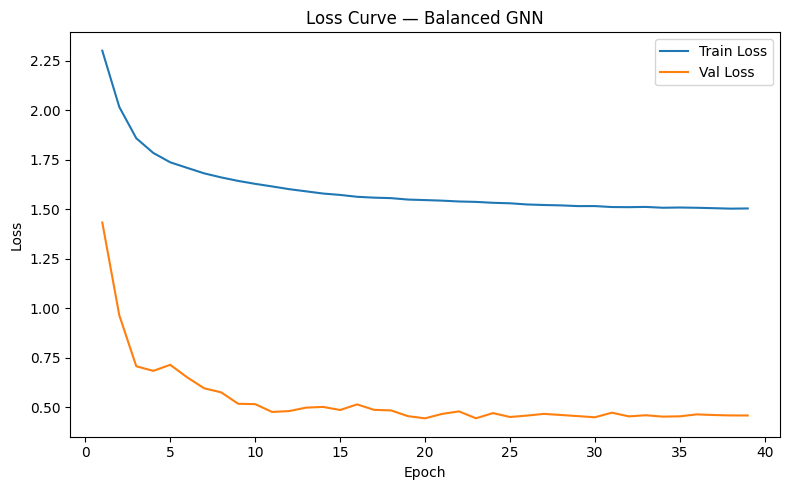

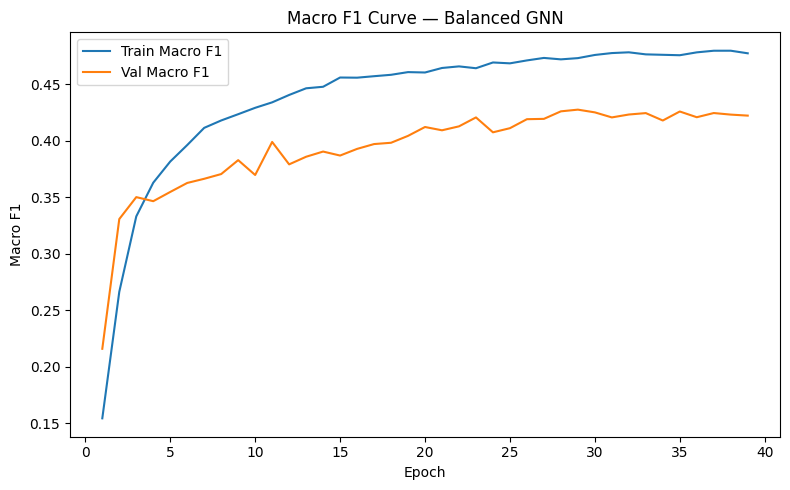

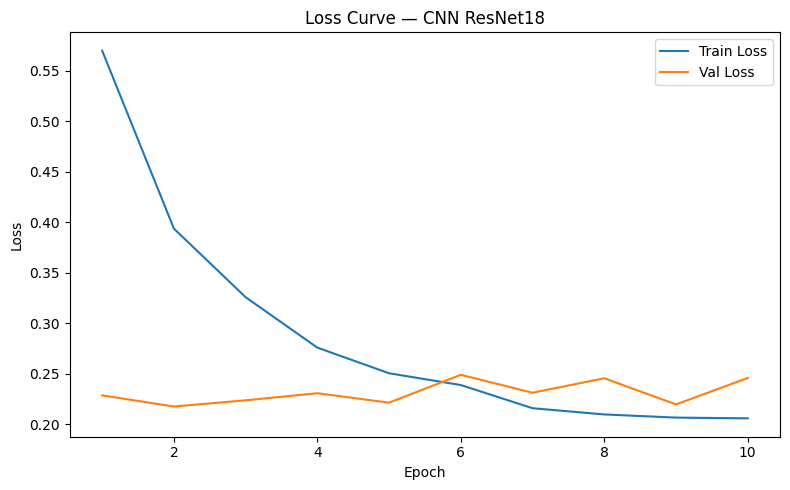

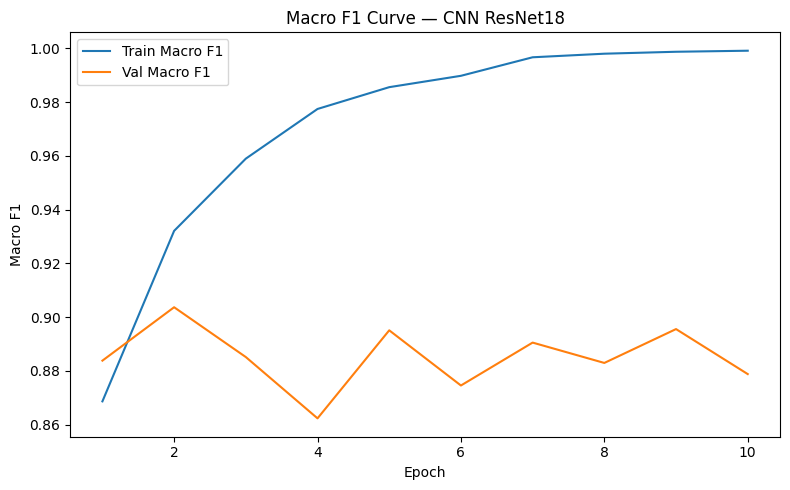

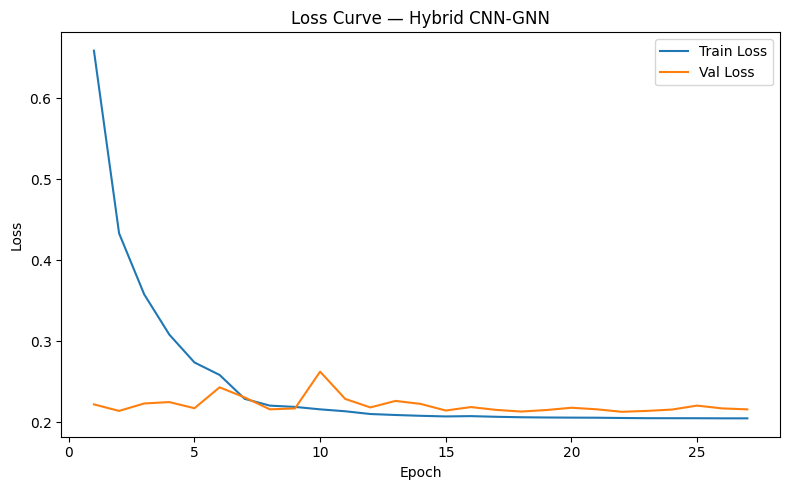

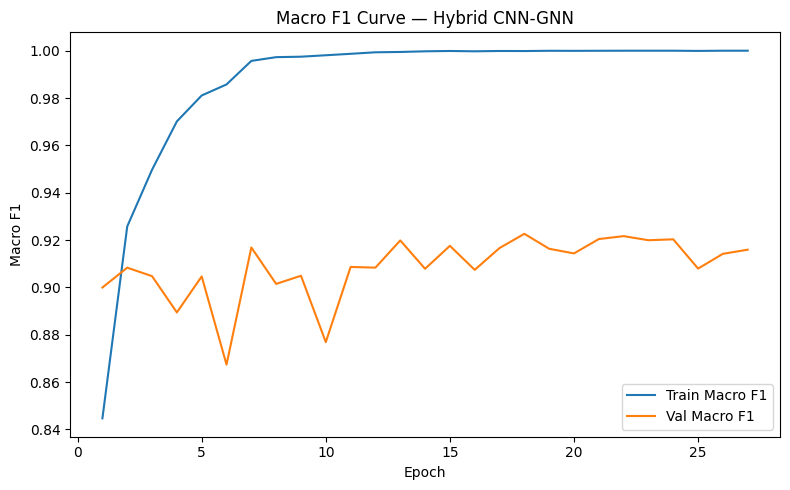

In [ ]:
# ============================================================
# 20) Plot training curves
# ============================================================

history_files = {
    "Balanced GNN": GNN_BEST_PATH.replace(".pt", "_history.csv"),
    "CNN ResNet18": CNN_BEST_PATH.replace(".pt", "_history.csv"),
    "Hybrid CNN-GNN": HYBRID_BEST_PATH.replace(".pt", "_history.csv"),
}

for name, hp in history_files.items():
    if not os.path.exists(hp):
        print("Missing history:", hp)
        continue
    df = pd.read_csv(hp)

    plt.figure(figsize=(8, 5))
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
    plt.title(f"Loss Curve — {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{name.lower().replace(' ', '_')}_loss_curve.png"), dpi=220)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(df["epoch"], df["train_macro_f1"], label="Train Macro F1")
    plt.plot(df["epoch"], df["val_macro_f1"], label="Val Macro F1")
    plt.title(f"Macro F1 Curve — {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{name.lower().replace(' ', '_')}_macro_f1_curve.png"), dpi=220)
    plt.show()

## Cell 21 — Save Results Zip and Copy to Google Drive

This creates a downloadable ZIP file containing evaluation CSVs, confusion matrices, plots, and comparison results.

In [ ]:
# ============================================================
# 21) Save results zip
# ============================================================

zip_base = "/content/fydp_improved_results"
zip_path = shutil.make_archive(zip_base, "zip", RESULTS_DIR)
print("Results zip created:", zip_path)

# Copy zip to Drive project folder.
drive_zip_path = os.path.join(PROJECT_DIR, "fydp_improved_results.zip")
shutil.copy(zip_path, drive_zip_path)
print("Results zip copied to Drive:", drive_zip_path)

# Download directly from Colab.
from google.colab import files
files.download(zip_path)

Results zip created: /content/fydp_improved_results.zip
Results zip copied to Drive: /content/drive/MyDrive/blood_cell_improved_project/fydp_improved_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 22 — Create Professional Dashboard App

This section creates the final dashboard app in a clean and readable way.

First run **Cell 22A** to mount Google Drive and create the app folder. Then run **Cell 22B** to write the complete `app.py` file.

This app/dashboard layer does **not** change the training strategy, data balancing, CNN model, GNN model, hybrid model, or evaluation results.


In [ ]:
# ============================================================
# 22A) Prepare Google Drive app folder
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os

APP_DIR = "/content/drive/MyDrive/blood_cell_app"
os.makedirs(APP_DIR, exist_ok=True)
os.makedirs(f"{APP_DIR}/reports", exist_ok=True)

print("App folder is ready:", APP_DIR)
print("Next: run Cell 22B to write app.py")


Mounted at /content/drive
App folder is ready: /content/drive/MyDrive/blood_cell_app
Next: run Cell 22B to write app.py


In [ ]:
%%writefile /content/drive/MyDrive/blood_cell_app/app.py

# ============================================================
# FINAL BLOOD CELL CLASSIFICATION DASHBOARD
# Old dashboard style + new improved model support
# ============================================================

import os
import json
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gradio as gr

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool

from torchvision.models import resnet18

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.pdfgen import canvas


# ============================================================
# Paths and Classes
# ============================================================

APP_DIR = "/content/drive/MyDrive/blood_cell_app"
PROJECT_DIR = "/content/drive/MyDrive/blood_cell_improved_project"
REPORTS_DIR = f"{APP_DIR}/reports"
os.makedirs(APP_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

CLASS_NAMES_PATH = f"{PROJECT_DIR}/class_names.json"
DEFAULT_CLASS_NAMES = ['BA', 'BNE', 'EO', 'ERB', 'LY', 'MMY', 'MO', 'MY', 'PLT', 'PMY', 'RBC', 'SNE']

if os.path.exists(CLASS_NAMES_PATH):
    with open(CLASS_NAMES_PATH, 'r') as f:
        CLASS_NAMES = json.load(f)
else:
    CLASS_NAMES = DEFAULT_CLASS_NAMES

NUM_CLASSES = len(CLASS_NAMES)

CELL_FULL_NAMES = {
    'BA': 'Basophil',
    'BNE': 'Band Neutrophil',
    'EO': 'Eosinophil',
    'ERB': 'Erythroblast',
    'LY': 'Lymphocyte',
    'MMY': 'Metamyelocyte',
    'MO': 'Monocyte',
    'MY': 'Myelocyte',
    'PLT': 'Platelet',
    'PMY': 'Promyelocyte',
    'RBC': 'Red Blood Cell',
    'SNE': 'Segmented Neutrophil'
}

CELL_DESCRIPTIONS = {
    'BA': 'A granulocytic white blood cell involved in immune and inflammatory responses.',
    'BNE': 'An immature neutrophil stage often associated with active immune response or infection-related changes.',
    'EO': 'A granulocytic white blood cell commonly linked with allergic response and parasitic infection response.',
    'ERB': 'An immature red blood cell precursor. Its presence may be relevant for erythropoietic activity assessment.',
    'LY': 'A lymphoid white blood cell involved in adaptive immune response.',
    'MMY': 'An immature myeloid precursor cell. Increased presence may support abnormal myeloid activity screening.',
    'MO': 'A large white blood cell involved in immune defense and phagocytosis.',
    'MY': 'An immature myeloid precursor cell. It can be relevant in screening abnormal blood cell maturation.',
    'PLT': 'A platelet fragment involved in clotting and hemostasis.',
    'PMY': 'A very immature myeloid precursor cell. Its detection can be important for leukemia-related screening.',
    'RBC': 'A red blood cell responsible for oxygen transport. It is relevant for anemia-related analysis.',
    'SNE': 'A mature segmented neutrophil involved in immune defense against infection.'
}

DISEASE_ANALYSIS = {
    'RBC': 'The detected cell belongs to the red blood cell lineage. This supports the framework applicability for anemia-related screening when analyzed with RBC morphology, count, and distribution patterns.',
    'ERB': 'The detected cell is an immature red blood cell precursor. This may be relevant for disease-level analysis of abnormal erythropoiesis and anemia-related hematological assessment.',
    'PMY': 'The detected cell is an early immature myeloid precursor. Detection of such immature cells is important for leukemia-related screening and abnormal myeloid maturation analysis.',
    'MY': 'The detected cell is an immature myeloid precursor. Its identification supports disease-level interpretation related to abnormal myeloid development and possible leukemia screening.',
    'MMY': 'The detected cell is a myeloid precursor stage. Increased occurrence of such cells may support screening of abnormal hematological conditions.',
    'BNE': 'The detected cell is an immature neutrophil stage. It can be useful for analyzing immune response and abnormal granulocytic activity.',
    'LY': 'The detected lymphocyte can support white blood cell pattern analysis. Abnormal lymphocyte distribution may be relevant for hematological disease screening.',
    'MO': 'The detected monocyte can support immune-cell distribution analysis and disease-level hematological interpretation.',
    'SNE': 'The detected mature neutrophil supports white blood cell differential analysis, useful for infection or immune-response-related interpretation.',
    'EO': 'The detected eosinophil supports differential blood cell analysis, especially for allergic or parasitic-response-related screening.',
    'BA': 'The detected basophil supports differential white blood cell analysis and immune-response-related interpretation.',
    'PLT': 'The detected platelet supports blood component analysis related to clotting and platelet distribution assessment.'
}

LAST_REPORT_DATA = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Image Processing and Graph Construction
# ============================================================

def segment_cell_mask(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Keep foreground as the cell region.
    if th.mean() > 127:
        th = 255 - th

    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)
    return th


def segment_nucleus_kmeans(img_bgr, min_ratio=0.01, max_ratio=0.75):
    cell_mask = segment_cell_mask(img_bgr)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    ys, xs = np.where(cell_mask > 0)
    if len(xs) < 80:
        return np.zeros_like(cell_mask)

    feats = np.stack([lab[ys, xs, 1], lab[ys, xs, 2], gray[ys, xs]], axis=1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 60, 0.2)
    _, labels, centers = cv2.kmeans(feats, 2, None, criteria, 5, cv2.KMEANS_PP_CENTERS)

    # Nucleus is usually the darker cluster.
    nuc_cluster = int(np.argmin(centers[:, 2]))
    nuc_mask = np.zeros_like(cell_mask)
    pick = labels.flatten() == nuc_cluster
    nuc_mask[ys[pick], xs[pick]] = 255

    nuc_mask = cv2.morphologyEx(nuc_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    nuc_mask = cv2.morphologyEx(nuc_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=1)

    cnts, _ = cv2.findContours(nuc_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final = np.zeros_like(nuc_mask)

    if cnts:
        c = max(cnts, key=cv2.contourArea)
        nucleus_area = cv2.contourArea(c)
        cell_area = float(np.count_nonzero(cell_mask))
        ratio = nucleus_area / (cell_area + 1e-6)
        if min_ratio < ratio < max_ratio:
            cv2.drawContours(final, [c], -1, 255, -1)

    return final


def region_features(img_bgr, mask):
    if mask is None or np.count_nonzero(mask) < 10:
        return np.zeros(12, dtype=np.float32)

    ys, xs = np.where(mask > 0)
    region = img_bgr[ys, xs]
    area = float(len(xs))
    H, W = img_bgr.shape[:2]
    area_norm = area / float(H * W + 1e-6)
    x_mean = float(xs.mean()) / float(W + 1e-6)
    y_mean = float(ys.mean()) / float(H + 1e-6)

    b_mean, g_mean, r_mean = region.mean(axis=0) / 255.0
    b_std, g_std, r_std = region.std(axis=0) / 255.0

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        perim = cv2.arcLength(c, True)
        contour_area = cv2.contourArea(c)
        perim_norm = float(perim) / float(2 * (H + W) + 1e-6)
        circularity = float(4 * np.pi * contour_area / ((perim ** 2) + 1e-6))
    else:
        perim_norm = 0.0
        circularity = 0.0

    return np.array([
        area_norm, x_mean, y_mean,
        b_mean, g_mean, r_mean,
        b_std, g_std, r_std,
        perim_norm, circularity,
        1.0,
    ], dtype=np.float32)


def build_cell_graph_with_masks(img_bgr):
    cell_mask = segment_cell_mask(img_bgr)
    nuc_mask = segment_nucleus_kmeans(img_bgr)

    cyto_mask = None
    if np.count_nonzero(nuc_mask) > 20:
        cyto_mask = cv2.bitwise_and(cell_mask, cv2.bitwise_not(nuc_mask))

    node_feats = []
    node_types = []

    node_feats.append(region_features(img_bgr, cell_mask))
    node_types.append(0)

    if np.count_nonzero(nuc_mask) > 20:
        node_feats.append(region_features(img_bgr, nuc_mask))
        node_types.append(1)
        if cyto_mask is not None and np.count_nonzero(cyto_mask) > 20:
            node_feats.append(region_features(img_bgr, cyto_mask))
            node_types.append(2)

    x = torch.tensor(np.stack(node_feats, axis=0), dtype=torch.float)
    n = x.size(0)
    edges = []
    for i in range(n):
        for j in range(n):
            if i != j:
                edges.append([i, j])

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    graph = Data(x=x, edge_index=edge_index, y=torch.tensor([0], dtype=torch.long))
    graph.node_types = torch.tensor(node_types, dtype=torch.long)
    return graph, cell_mask, nuc_mask


# ============================================================
# Image Tensor Helper for CNN / Hybrid Model
# ============================================================

IMG_SIZE = 224
IMAGE_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGE_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def image_rgb_to_tensor(img_rgb, img_size=IMG_SIZE):
    img_rgb = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    img = img_rgb.astype(np.float32) / 255.0
    img = (img - IMAGE_MEAN) / IMAGE_STD
    img = np.transpose(img, (2, 0, 1))
    return torch.tensor(img, dtype=torch.float32)


# ============================================================
# Model Definitions Matching the Improved Notebook
# ============================================================

class GCNClassifier(nn.Module):
    def __init__(self, in_dim=12, hidden=96, num_classes=NUM_CLASSES, dropout=0.30):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.dropout = dropout
        self.lin = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        g = global_mean_pool(x, batch)
        return self.lin(g)


class OldGCNClassifier(nn.Module):
    """Fallback architecture for the previous dashboard model best_gnn.pt."""
    def __init__(self, in_dim=12, hidden=64, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin = nn.Linear(hidden, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        g = global_mean_pool(x, batch)
        out = self.lin(g)
        return out


def build_resnet18_backbone():
    backbone = resnet18(weights=None)
    feat_dim = backbone.fc.in_features
    backbone.fc = nn.Identity()
    return backbone, feat_dim


class CNNClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.35):
        super().__init__()
        self.backbone, feat_dim = build_resnet18_backbone()
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, images):
        feat = self.backbone(images)
        return self.classifier(feat)


class GraphEncoder(nn.Module):
    def __init__(self, in_dim=12, hidden=96, dropout=0.25):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        g = global_mean_pool(x, batch)
        return g


class HybridCNNGNNClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.35):
        super().__init__()
        self.cnn_backbone, cnn_dim = build_resnet18_backbone()
        self.graph_encoder = GraphEncoder(in_dim=12, hidden=96, dropout=0.25)
        self.fusion = nn.Sequential(
            nn.Linear(cnn_dim + 96, 384),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, images, graphs):
        image_feat = self.cnn_backbone(images)
        graph_feat = self.graph_encoder(graphs)
        fused = torch.cat([image_feat, graph_feat], dim=1)
        return self.fusion(fused)


# ============================================================
# Load Best Available Model
# Priority: Hybrid → CNN → Balanced GNN → Old GNN
# ============================================================

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    return checkpoint


def load_model_safely(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = extract_state_dict(checkpoint)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def load_best_available_model():
    candidates = [
        ("Hybrid CNN + GNN", "hybrid", f"{PROJECT_DIR}/best_hybrid_cnn_gnn.pt"),
        ("CNN ResNet18", "cnn", f"{PROJECT_DIR}/best_cnn_resnet18.pt"),
        ("Balanced GNN", "gnn", f"{PROJECT_DIR}/best_balanced_gnn.pt"),
        ("Previous Dashboard GNN", "old_gnn", f"{APP_DIR}/best_gnn.pt"),
    ]

    errors = []
    for display_name, model_type, path in candidates:
        if not os.path.exists(path):
            continue
        try:
            if model_type == "hybrid":
                model = HybridCNNGNNClassifier(num_classes=NUM_CLASSES, dropout=0.35)
            elif model_type == "cnn":
                model = CNNClassifier(num_classes=NUM_CLASSES, dropout=0.35)
            elif model_type == "gnn":
                model = GCNClassifier(in_dim=12, hidden=96, num_classes=NUM_CLASSES, dropout=0.30)
            else:
                model = OldGCNClassifier(in_dim=12, hidden=64, num_classes=NUM_CLASSES)

            model = load_model_safely(model, path)
            return model, model_type, display_name, path, []
        except Exception as e:
            errors.append(f"{display_name}: {str(e)}")

    return None, None, "No trained model found", None, errors


model, ACTIVE_MODEL_TYPE, ACTIVE_MODEL_DISPLAY, ACTIVE_MODEL_PATH, MODEL_LOAD_ERRORS = load_best_available_model()

print("Dashboard model status:", ACTIVE_MODEL_DISPLAY)
print("Model type:", ACTIVE_MODEL_TYPE)
print("Model path:", ACTIVE_MODEL_PATH)
print("Device:", device)
if MODEL_LOAD_ERRORS:
    print("Model load warnings:")
    for err in MODEL_LOAD_ERRORS:
        print("-", err)


# ============================================================
# PDF Report Generation
# ============================================================

class ReportFooterCanvas(canvas.Canvas):
    def __init__(self, *args, **kwargs):
        canvas.Canvas.__init__(self, *args, **kwargs)
        self.pages = []

    def showPage(self):
        self.pages.append(dict(self.__dict__))
        self._startPage()

    def save(self):
        page_count = len(self.pages)
        for page in self.pages:
            self.__dict__.update(page)
            self.draw_footer(page_count)
            canvas.Canvas.showPage(self)
        canvas.Canvas.save(self)

    def draw_footer(self, page_count):
        self.saveState()
        self.setFont("Helvetica", 8)
        self.setFillColor(colors.HexColor("#64748B"))
        self.drawString(0.75 * inch, 0.45 * inch, "FYDP Blood Cell Classification Dashboard")
        self.drawRightString(7.5 * inch, 0.45 * inch, f"Page {self._pageNumber} of {page_count}")
        self.restoreState()


def safe_text(value):
    if value is None:
        return ""
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


def generate_pdf_report():
    if not LAST_REPORT_DATA:
        return None

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    pdf_path = f"{REPORTS_DIR}/blood_cell_report_{timestamp}.pdf"

    doc = SimpleDocTemplate(
        pdf_path,
        pagesize=A4,
        rightMargin=0.65 * inch,
        leftMargin=0.65 * inch,
        topMargin=0.70 * inch,
        bottomMargin=0.70 * inch,
    )

    styles = getSampleStyleSheet()

    title_style = ParagraphStyle(
        "CustomTitle",
        parent=styles["Title"],
        fontSize=20,
        leading=26,
        textColor=colors.HexColor("#0F172A"),
        spaceAfter=10,
    )

    subtitle_style = ParagraphStyle(
        "Subtitle",
        parent=styles["BodyText"],
        fontSize=10.5,
        leading=14,
        textColor=colors.HexColor("#475569"),
        spaceAfter=12,
    )

    section_style = ParagraphStyle(
        "SectionTitle",
        parent=styles["Heading2"],
        fontSize=12.5,
        leading=16,
        textColor=colors.HexColor("#1D4ED8"),
        spaceBefore=12,
        spaceAfter=7,
    )

    body_style = ParagraphStyle(
        "BodyTextClean",
        parent=styles["BodyText"],
        fontSize=10.2,
        leading=15,
        textColor=colors.HexColor("#334155"),
        spaceAfter=6,
    )

    note_style = ParagraphStyle(
        "NoteStyle",
        parent=styles["BodyText"],
        fontSize=9.5,
        leading=14,
        textColor=colors.HexColor("#64748B"),
        spaceAfter=6,
    )

    story = []

    pred_class = safe_text(LAST_REPORT_DATA.get("pred_class"))
    cell_name = safe_text(LAST_REPORT_DATA.get("cell_full_name"))
    confidence = float(LAST_REPORT_DATA.get("confidence", 0))
    disease_category = safe_text(LAST_REPORT_DATA.get("disease_category"))
    model_used = safe_text(LAST_REPORT_DATA.get("model_display"))
    image_type = safe_text(LAST_REPORT_DATA.get("image_type"))
    generated_at = safe_text(LAST_REPORT_DATA.get("generated_at"))
    cell_description = safe_text(LAST_REPORT_DATA.get("cell_description"))
    disease_note = safe_text(LAST_REPORT_DATA.get("disease_note"))

    if confidence >= 0.90:
        confidence_level = "High confidence prediction"
        confidence_explanation = (
            "The model prediction is strong because the predicted class has a high probability score. "
            "This indicates that the visual and morphological patterns of the uploaded cell are clearly aligned "
            "with the predicted blood cell class."
        )
    elif confidence >= 0.70:
        confidence_level = "Moderate confidence prediction"
        confidence_explanation = (
            "The model prediction is acceptable, but some visual similarity with other blood cell classes may exist. "
            "The result should be interpreted carefully, especially if the uploaded image quality is low."
        )
    else:
        confidence_level = "Low confidence prediction"
        confidence_explanation = (
            "The model confidence is low. This may happen due to poor image quality, unclear cell boundaries, "
            "overlapping cells, or similarity between multiple blood cell classes. Expert review is recommended."
        )

    story.append(Paragraph("Blood Cell Classification and Disease-Level Analysis Report", title_style))
    story.append(Paragraph(
        "AI Hematology Suite — Hybrid CNN-GNN FYDP Research Prototype",
        subtitle_style
    ))

    story.append(Paragraph("1. Prediction Summary", section_style))

    summary_data = [
        ["Predicted Class Code", pred_class],
        ["Identified Cell", cell_name],
        ["Prediction Confidence", f"{confidence * 100:.2f}%"],
        ["Confidence Level", confidence_level],
        ["Disease Screening Category", disease_category],
        ["Model Used", model_used],
        ["Image Type", image_type],
        ["Generated At", generated_at],
    ]

    summary_table = Table(summary_data, colWidths=[2.25 * inch, 4.45 * inch])
    summary_table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (0, -1), colors.HexColor("#EFF6FF")),
        ("TEXTCOLOR", (0, 0), (0, -1), colors.HexColor("#1E3A8A")),
        ("TEXTCOLOR", (1, 0), (1, -1), colors.HexColor("#0F172A")),
        ("FONTNAME", (0, 0), (0, -1), "Helvetica-Bold"),
        ("FONTNAME", (1, 0), (1, -1), "Helvetica"),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.35, colors.HexColor("#CBD5E1")),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 8),
        ("TOPPADDING", (0, 0), (-1, -1), 8),
    ]))
    story.append(summary_table)

    story.append(Paragraph("2. Cell-Level Morphological Interpretation", section_style))
    story.append(Paragraph(cell_description, body_style))
    story.append(Paragraph(
        "The prediction is based on visual and morphological characteristics observed from the uploaded blood cell image. "
        "These characteristics may include cell shape, cytoplasm appearance, nucleus pattern, granules, color distribution, "
        "and other microscopic image features learned by the trained model.",
        body_style
    ))

    story.append(Paragraph("3. Disease-Level Analysis", section_style))
    story.append(Paragraph(disease_note, body_style))
    story.append(Paragraph(
        "At disease level, this system does not depend on a single cell only. A stronger interpretation is achieved when "
        "multiple blood cells are analyzed together and their class distribution patterns are compared. For example, abnormal "
        "red blood cell related patterns may support anemia-related screening, while abnormal immature white blood cell patterns "
        "may support leukemia-related screening.",
        body_style
    ))

    story.append(Paragraph("4. Confidence Interpretation", section_style))
    story.append(Paragraph(confidence_explanation, body_style))

    story.append(Paragraph("5. Top 3 Model Predictions", section_style))
    top3_rows = [["Rank", "Class", "Confidence"]]
    for rank, (cls_name, prob) in enumerate(LAST_REPORT_DATA.get("top3", []), start=1):
        top3_rows.append([str(rank), safe_text(cls_name), f"{prob * 100:.2f}%"])

    top3_table = Table(top3_rows, colWidths=[0.8 * inch, 2.5 * inch, 1.7 * inch])
    top3_table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#0F172A")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.35, colors.HexColor("#CBD5E1")),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
    ]))
    story.append(top3_table)

    story.append(Paragraph("6. Model and Framework Explanation", section_style))
    story.append(Paragraph(
        "The final system uses a Hybrid CNN-GNN approach. The CNN branch extracts deep visual image features such as "
        "texture, color, nucleus shape, cytoplasm pattern, and granules. The GNN branch models morphology-based structural "
        "relationships between important cell components such as the whole cell, nucleus, and cytoplasm. The fused features "
        "are then used for final blood cell classification.",
        body_style
    ))

    story.append(Paragraph("7. Clinical Note and Limitation", section_style))
    story.append(Paragraph(
        "This report is generated by a computational research prototype. It is intended for educational, research, and "
        "decision-support purposes only. It is not a final clinical diagnosis. Reliable disease-level decision making requires "
        "multiple cell images, complete blood count values, laboratory findings, patient history, and expert medical validation.",
        note_style
    ))

    story.append(Paragraph("8. Recommendation", section_style))
    story.append(Paragraph(
        "For stronger disease-level analysis, upload multiple clear cropped blood cell images from the same sample and compare "
        "the distribution of predicted classes. Low-quality, blurred, overlapping, or uncropped images may reduce prediction reliability.",
        body_style
    ))

    doc.build(story, canvasmaker=ReportFooterCanvas)
    return pdf_path


def download_pdf_report():
    pdf_path = generate_pdf_report()
    if pdf_path is None:
        return None, "Please run prediction first, then generate the PDF report."
    return pdf_path, f"PDF report generated successfully and saved in Google Drive:\n{pdf_path}"


# ============================================================
# Prediction Function
# ============================================================

def disease_category_for_class(pred_class):
    if pred_class in ["RBC", "ERB"]:
        return "Anemia-related hematological screening"
    if pred_class in ["PMY", "MY", "MMY", "BNE"]:
        return "Leukemia / abnormal myeloid maturation screening"
    if pred_class in ["LY", "MO", "SNE", "EO", "BA"]:
        return "White blood cell differential and immune-response analysis"
    if pred_class == "PLT":
        return "Platelet-related blood component analysis"
    return "General hematological analysis"


def predict_cell(image_rgb, image_type):
    global LAST_REPORT_DATA

    if image_rgb is None:
        return (
            "Please upload a blood cell image first.",
            {},
            "No prediction available.",
            None
        )

    if model is None:
        message = """
# Model Not Found

No trained model checkpoint was found yet.

Please train at least one model in the improved notebook first. The dashboard will automatically use the best available model in this order:

1. Hybrid CNN + GNN
2. CNN ResNet18
3. Balanced GNN
4. Previous dashboard GNN
"""
        if MODEL_LOAD_ERRORS:
            message += "\nModel loading warnings:\n" + "\n".join([f"- {e}" for e in MODEL_LOAD_ERRORS])
        return message, {}, "Model not loaded.", None

    try:
        img_rgb = np.array(image_rgb)

        if img_rgb.ndim == 2:
            img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)

        if img_rgb.shape[-1] == 4:
            img_rgb = img_rgb[:, :, :3]

        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

        graph, cell_mask, nuc_mask = build_cell_graph_with_masks(img_bgr)
        graph = Batch.from_data_list([graph]).to(device)

        image_tensor = image_rgb_to_tensor(img_rgb).unsqueeze(0).to(device)

        with torch.no_grad():
            if ACTIVE_MODEL_TYPE == "hybrid":
                logits = model(image_tensor, graph)
            elif ACTIVE_MODEL_TYPE == "cnn":
                logits = model(image_tensor)
            else:
                logits = model(graph)

            probs = F.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = int(np.argmax(probs))
        pred_class = CLASS_NAMES[pred_idx]
        confidence = float(probs[pred_idx])
        sorted_indices = np.argsort(probs)[::-1]

        cell_full_name = CELL_FULL_NAMES.get(pred_class, pred_class)
        cell_description = CELL_DESCRIPTIONS.get(pred_class, "No cell description available.")
        disease_note = DISEASE_ANALYSIS.get(pred_class, "Disease-level interpretation is not available for this class.")
        disease_category = disease_category_for_class(pred_class)

        LAST_REPORT_DATA = {
            "pred_class": pred_class,
            "cell_full_name": cell_full_name,
            "confidence": confidence,
            "cell_description": cell_description,
            "disease_note": disease_note,
            "disease_category": disease_category,
            "image_type": image_type,
            "top3": [(CLASS_NAMES[int(idx)], float(probs[int(idx)])) for idx in sorted_indices[:3]],
            "probabilities": {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))},
            "model_display": ACTIVE_MODEL_DISPLAY,
            "model_type": ACTIVE_MODEL_TYPE,
            "model_path": ACTIVE_MODEL_PATH,
            "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }

        report_markdown = f"""
# Cell Identification Report

## Final Classification

**Predicted Class Code:** `{pred_class}`

**Identified Cell:** **{cell_full_name}**

**Confidence Score:** **{confidence * 100:.2f}%**

**Model Used:** **{ACTIVE_MODEL_DISPLAY}**

---

## Cell-Level Morphological Interpretation

{cell_description}

---

## Disease-Level Analysis

{disease_note}

---

## Disease Screening Category

**{disease_category}**

---

## Framework Relevance

The uploaded blood cell image is processed through the final trained model. The improved notebook keeps the accuracy strategy unchanged and uses the best available trained model for dashboard prediction.

This demonstrates the applicability of the proposed framework for hematological disease screening, including:

- Anemia-related analysis
- Leukemia-related abnormal cell maturation analysis
- White blood cell differential assessment
- General blood cell morphology-based interpretation

---

## Selected Image Type

{image_type}

---

## Clinical Note

This output is a **computational screening interpretation** based on image morphology and trained model prediction. It is **not a clinical diagnosis**.

For reliable disease-level decision making, multiple cell images, cell count distribution, laboratory findings, and expert medical validation are required.
"""

        prob_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

        top3_text = "Top 3 Predictions\n\n"
        for rank, idx in enumerate(sorted_indices[:3], start=1):
            top3_text += f"{rank}. {CLASS_NAMES[idx]} : {probs[idx] * 100:.2f}%\n"

        cell_mask_rgb = cv2.cvtColor(cell_mask, cv2.COLOR_GRAY2RGB)
        nuc_mask_rgb = cv2.cvtColor(nuc_mask, cv2.COLOR_GRAY2RGB)

        h, w = img_rgb.shape[:2]
        cell_mask_rgb = cv2.resize(cell_mask_rgb, (w, h))
        nuc_mask_rgb = cv2.resize(nuc_mask_rgb, (w, h))

        combined = np.concatenate([img_rgb, cell_mask_rgb, nuc_mask_rgb], axis=1)

        return report_markdown, prob_dict, top3_text, combined

    except Exception as e:
        error_text = f"""
# Prediction Error

{str(e)}

Please try uploading a clear cropped blood cell image.
"""
        return error_text, {}, "Prediction failed.", None


# ============================================================
# Dashboard CSS — same polished style as previous app
# ============================================================

custom_css = """
body {
    background:
        radial-gradient(circle at top left, rgba(37, 99, 235, 0.10), transparent 28%),
        radial-gradient(circle at top right, rgba(14, 165, 233, 0.08), transparent 22%),
        linear-gradient(180deg, #f5f8fc 0%, #eef3f9 100%);
    font-family: 'Inter', 'Segoe UI', sans-serif;
    color: #0f172a;
}

.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    padding-top: 18px !important;
    padding-bottom: 24px !important;
    background: transparent !important;
}

#header-card {
    position: relative;
    overflow: hidden;
    background: linear-gradient(135deg, #ffffff 0%, #f8fbff 55%, #f1f7ff 100%);
    border: 1px solid rgba(148, 163, 184, 0.22);
    border-radius: 28px;
    padding: 30px 32px;
    box-shadow: 0 18px 50px rgba(15, 23, 42, 0.08);
    margin-bottom: 24px;
}

#header-card::before {
    content: '';
    position: absolute;
    inset: 0 auto auto 0;
    width: 100%;
    height: 5px;
    background: linear-gradient(90deg, #1d4ed8, #0ea5e9, #10b981);
}

.brand-badge {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    padding: 8px 14px;
    border-radius: 999px;
    background: rgba(37, 99, 235, 0.08);
    border: 1px solid rgba(37, 99, 235, 0.12);
    color: #1d4ed8;
    font-size: 12px;
    font-weight: 800;
    letter-spacing: 0.04em;
    text-transform: uppercase;
    margin-bottom: 14px;
}

#main-title {
    color: #0f172a;
    font-size: 38px;
    font-weight: 900;
    line-height: 1.12;
    letter-spacing: -0.03em;
    margin-bottom: 8px;
}

#subtitle {
    color: #475569;
    font-size: 16px;
    line-height: 1.65;
    max-width: 920px;
    margin-bottom: 22px;
}

.hero-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 14px;
    margin-bottom: 20px;
}

.hero-stat-card {
    background: linear-gradient(180deg, #ffffff 0%, #f8fbff 100%);
    border: 1px solid #e2e8f0;
    border-radius: 18px;
    padding: 16px 18px;
    box-shadow: 0 10px 24px rgba(15, 23, 42, 0.05);
}

.hero-stat-label {
    color: #64748b;
    font-size: 12px;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    margin-bottom: 6px;
}

.hero-stat-value {
    color: #0f172a;
    font-size: 22px;
    font-weight: 900;
    margin-bottom: 4px;
}

.hero-stat-subtitle {
    color: #475569;
    font-size: 13px;
    line-height: 1.5;
}

.card {
    background: rgba(255, 255, 255, 0.88);
    backdrop-filter: blur(6px);
    border-radius: 24px;
    padding: 22px;
    border: 1px solid rgba(226, 232, 240, 0.95);
    box-shadow: 0 16px 40px rgba(15, 23, 42, 0.07);
}

.section-title {
    display: flex;
    align-items: center;
    gap: 10px;
    color: #0f172a;
    font-size: 18px;
    font-weight: 850;
    margin-bottom: 16px;
    letter-spacing: -0.01em;
}

.section-title::before {
    content: '';
    width: 6px;
    height: 22px;
    border-radius: 999px;
    background: linear-gradient(180deg, #2563eb, #0ea5e9);
    display: inline-block;
}

.info-box,
.warning-box,
.model-box {
    border-radius: 18px;
    padding: 16px 18px;
    font-size: 14px;
    line-height: 1.65;
    border: 1px solid transparent;
}

.info-box {
    background: linear-gradient(135deg, rgba(37, 99, 235, 0.07), rgba(14, 165, 233, 0.06));
    border-color: rgba(37, 99, 235, 0.12);
    color: #1e3a8a;
}

.warning-box {
    background: linear-gradient(135deg, rgba(249, 115, 22, 0.08), rgba(251, 191, 36, 0.06));
    border-color: rgba(249, 115, 22, 0.14);
    color: #9a3412;
    margin-top: 16px;
}

.model-box {
    background: linear-gradient(135deg, rgba(16, 185, 129, 0.08), rgba(34, 197, 94, 0.06));
    border-color: rgba(22, 163, 74, 0.14);
    color: #14532d;
    margin-top: 16px;
}

.status-heading {
    margin-top: 22px;
    margin-bottom: 14px;
    color: #0f172a;
    font-size: 16px;
    font-weight: 850;
}

.objective-grid {
    display: grid;
    grid-template-columns: repeat(5, minmax(0, 1fr));
    gap: 12px;
    margin-top: 10px;
}

.objective-card {
    background: linear-gradient(180deg, #ffffff 0%, #f8fafc 100%);
    border: 1px solid #e2e8f0;
    border-radius: 18px;
    padding: 16px 12px;
    text-align: center;
    box-shadow: 0 8px 20px rgba(15, 23, 42, 0.04);
}

.objective-check {
    display: inline-flex;
    align-items: center;
    justify-content: center;
    width: 34px;
    height: 34px;
    border-radius: 50%;
    background: rgba(22, 163, 74, 0.10);
    color: #15803d;
    font-size: 18px;
    font-weight: 900;
    margin-bottom: 8px;
}

.objective-title {
    color: #0f172a;
    font-size: 13px;
    font-weight: 800;
    margin-bottom: 4px;
}

.objective-subtitle {
    color: #64748b;
    font-size: 11px;
    line-height: 1.4;
}

button {
    border-radius: 16px !important;
    font-weight: 800 !important;
    background: linear-gradient(135deg, #0f172a 0%, #1d4ed8 60%, #0ea5e9 100%) !important;
    color: white !important;
    border: none !important;
    min-height: 48px !important;
    font-size: 15px !important;
    box-shadow: 0 12px 24px rgba(37, 99, 235, 0.20) !important;
    transition: all 0.25s ease !important;
}

button:hover {
    transform: translateY(-1px);
    box-shadow: 0 16px 28px rgba(37, 99, 235, 0.28) !important;
}

textarea, input {
    border-radius: 16px !important;
}

.footer-text {
    text-align: center;
    color: #64748b;
    font-size: 13px;
    line-height: 1.8;
    margin-top: 20px;
    padding: 8px 0 4px;
}

.class-pill {
    display: inline-block;
    background: linear-gradient(180deg, #ffffff 0%, #f7fafc 100%);
    color: #334155;
    padding: 7px 11px;
    border-radius: 999px;
    margin: 4px;
    font-size: 12px;
    font-weight: 700;
    border: 1px solid #e2e8f0;
}

footer {
    display: none !important;
}

@media (max-width: 1100px) {
    .objective-grid {
        grid-template-columns: repeat(3, minmax(0, 1fr));
    }
}

@media (max-width: 900px) {
    #header-card {
        padding: 24px 22px;
    }

    #main-title {
        font-size: 30px;
    }

    .hero-grid,
    .objective-grid {
        grid-template-columns: 1fr;
    }
}
"""


# ============================================================
# Dashboard Layout
# ============================================================

class_pills_html = "\n".join([f'<span class="class-pill">{c}</span>' for c in CLASS_NAMES])
model_status_html = f"""
<div class="model-box">
    <b>Active Model:</b> {ACTIVE_MODEL_DISPLAY}<br>
    <b>Model Type:</b> {ACTIVE_MODEL_TYPE if ACTIVE_MODEL_TYPE else 'Not loaded yet'}<br>
    <b>Checkpoint:</b> {ACTIVE_MODEL_PATH if ACTIVE_MODEL_PATH else 'Train a model first'}
</div>
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as interface:

    gr.HTML(f"""
    <div id="header-card">
        <div class="brand-badge">AI Hematology Suite</div>
        <div id="main-title">Blood Cell Classification Dashboard</div>
        <div id="subtitle">
            AI-powered blood cell image classification using the improved FYDP pipeline.
            The dashboard keeps the previous professional interface, but now it automatically uses the best available trained model:
            Hybrid CNN + GNN, CNN baseline, balanced GNN, or previous GNN fallback.
        </div>

        <div class="hero-grid">
            <div class="hero-stat-card">
                <div class="hero-stat-label">Model Scope</div>
                <div class="hero-stat-value">{NUM_CLASSES} Blood Cell Classes</div>
                <div class="hero-stat-subtitle">Covers white blood cells, red blood cell lineage, platelet class, and immature myeloid stages.</div>
            </div>

            <div class="hero-stat-card">
                <div class="hero-stat-label">Analysis Pipeline</div>
                <div class="hero-stat-value">Image → CNN/GNN → Report</div>
                <div class="hero-stat-subtitle">Uses deep visual features and morphology graph features depending on the trained checkpoint available.</div>
            </div>

            <div class="hero-stat-card">
                <div class="hero-stat-label">Reporting</div>
                <div class="hero-stat-value">Instant PDF Output</div>
                <div class="hero-stat-subtitle">Generates a professional report containing predicted class, confidence distribution, and disease-level notes.</div>
            </div>
        </div>

        <div class="info-box">
            <b>Recommended:</b> Upload one cropped blood cell image for the most reliable prediction.
            Full microscope images can still be tested, but results may be less reliable because the model was primarily trained on cropped single-cell images.
        </div>

        <div class="status-heading">Project Implementation Status</div>

        <div class="objective-grid">
            <div class="objective-card">
                <div class="objective-check">✓</div>
                <div class="objective-title">Balanced Data</div>
                <div class="objective-subtitle">Controlled class balancing and augmentation</div>
            </div>

            <div class="objective-card">
                <div class="objective-check">✓</div>
                <div class="objective-title">CNN Baseline</div>
                <div class="objective-subtitle">Deep visual feature learning</div>
            </div>

            <div class="objective-card">
                <div class="objective-check">✓</div>
                <div class="objective-title">GNN Features</div>
                <div class="objective-subtitle">Morphology graph representation</div>
            </div>

            <div class="objective-card">
                <div class="objective-check">✓</div>
                <div class="objective-title">Hybrid Model</div>
                <div class="objective-subtitle">CNN + GNN fusion support</div>
            </div>

            <div class="objective-card">
                <div class="objective-check">✓</div>
                <div class="objective-title">PDF Report</div>
                <div class="objective-subtitle">Professional downloadable report</div>
            </div>
        </div>
    </div>
    """)

    with gr.Row():

        with gr.Column(scale=1):
            with gr.Group(elem_classes="card"):
                gr.HTML('<div class="section-title">Upload Blood Cell Image</div>')

                input_image = gr.Image(
                    type="pil",
                    label="Blood Cell Image",
                    height=360
                )

                image_type = gr.Radio(
                    choices=[
                        "Cropped cell image - Recommended",
                        "Full image - Experimental"
                    ],
                    value="Cropped cell image - Recommended",
                    label="Image Type"
                )

                predict_btn = gr.Button("Run Prediction")

                gr.HTML("""
                <div class="warning-box">
                    <b>Demo Tip:</b> Use a clear cropped single-cell image for the cleanest and most reliable result.
                </div>
                """)

                gr.HTML(model_status_html)

        with gr.Column(scale=1):
            with gr.Group(elem_classes="card"):
                gr.HTML('<div class="section-title">Cell Identification Report and Disease-Level Interpretation</div>')

                result_output = gr.Markdown(label="Cell Identification Report")

                top3_output = gr.Textbox(label="Top 3 Predictions", lines=6)

                pdf_btn = gr.Button("Download Professional PDF Report")

                pdf_output = gr.File(label="Generated PDF Report - Click the file below to download")

                pdf_status = gr.Textbox(label="PDF Save Status", lines=2)

            with gr.Group(elem_classes="card"):
                gr.HTML('<div class="section-title">Class Probability Distribution</div>')

                prob_output = gr.Label(label="Class Probabilities", num_top_classes=12)

    with gr.Row():
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.HTML('<div class="section-title">Image Processing Preview</div>')

                preview_output = gr.Image(
                    label="Original Image | Cell Mask | Nucleus Mask",
                    height=280
                )

    gr.HTML(f"""
    <div class="footer-text">
        <b>Supported Model Classes</b><br>
        {class_pills_html}
    </div>
    """)

    predict_btn.click(
        fn=predict_cell,
        inputs=[input_image, image_type],
        outputs=[result_output, prob_output, top3_output, preview_output]
    )

    pdf_btn.click(
        fn=download_pdf_report,
        inputs=[],
        outputs=[pdf_output, pdf_status]
    )


interface.launch(
    share=True,
    inline=False,
    debug=True
)



Overwriting /content/drive/MyDrive/blood_cell_app/app.py


## Cell 23 — Launch Professional Dashboard App

Run this cell when you want to open the Gradio dashboard. The dashboard uses the same style as your previous app, including prediction report, class probabilities, image processing preview, disease-level explanation, and PDF report download.

This is only the presentation/dashboard layer. It does not retrain the model and does not affect the 90%+ improvement strategy.

In [ ]:
# ============================================================
# 23) Launch professional dashboard app
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# Install app dependencies. Run this launch cell after training at least one model.
!pip -q install gradio reportlab torch-geometric torchvision

app_path = "/content/drive/MyDrive/blood_cell_app/app.py"
print("Launching dashboard from:", app_path)

%run /content/drive/MyDrive/blood_cell_app/app.py


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.4 MB/s eta 0:00:00
Launching dashboard from: /content/drive/MyDrive/blood_cell_app/app.py
Dashboard model status: Hybrid CNN + GNN
Model type: hybrid
Model path: /content/drive/MyDrive/blood_cell_improved_project/best_hybrid_cnn_gnn.pt
Device: cuda


/content/drive/MyDrive/blood_cell_app/app.py:1143: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as interface:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a1d624255f2e93c1b4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
